# Battery Swelling Prediction Workflow

This notebook records the end-to-end workflow for:

1. dataset cleaning / subset preparation
2. frequency-domain ECM fitting
3. time-domain ECM fitting
4. model training
5. evaluation and plotting

It is designed to reuse the existing command-line scripts in this repo, while making the run history and outputs easier to inspect in one place.

## 0. Manual configuration

Set the output folder and dataset paths here before running anything else.

In [1]:
from pathlib import Path
import os
import subprocess
import shlex
import json
import shutil
import pandas as pd

REPO_ROOT = Path.cwd()

# Support running the notebook from the repo root, notebooks/, or src/.
if not (REPO_ROOT / "src").exists() and (REPO_ROOT.parent / "src").exists():
    REPO_ROOT = REPO_ROOT.parent

VENV_PYTHON = REPO_ROOT / ".venv" / "bin" / "python"

# -------------------------
# Manual run configuration
# -------------------------
RUN_NAME = "latest_test_26_5_20_2_repro"
OUTPUT_ROOT = REPO_ROOT / "data" / RUN_NAME
LOG_DIR = OUTPUT_ROOT / "logs"

# Generic dataset paths
WORKBOOK_XLSX_DIR = REPO_ROOT / "dataset" / "udc_xlsx"
RAW_DATA_DIR = REPO_ROOT / "dataset" / "raw_data"

# Example real local paths for this repo (edit as needed)
WORKBOOK_XLSX_DIR = REPO_ROOT / "dataset" / "OneDrive_1_2-20-2026" / "HYCL"
RAW_DATA_DIR = REPO_ROOT / "dataset" / "raw_data" / "HYCL"

# -------------------------------------------------
# Frequency-domain ECM fitting control
# -------------------------------------------------
# If True, rerun frequency-domain ECM fitting using the same pre15 seed subset used in 14_3.
# If False, skip fitting and reuse the previously generated td-compatible ECM directory from 14_3.
RERUN_FREQUENCY_ECM_FIT = False

# Exact frequency-domain seed workbook subset used in the 14_3 -> 14_6 chain.
WORKBOOK_PRIOR_SEED_DIR = REPO_ROOT / "data" / "latest_test_26_5_14_3" / "xlsx_prior_subset_pre15"

# Reuse the same td-compatible frequency-domain ECM results used in 14_3 by default.
EXISTING_ECM_DIR = REPO_ROOT / "data" / "latest_test_26_5_14_3" / "ecm_w_cycle_td_compatible_pre15"

# Output location if you choose to rerun td-compatible frequency ECM fitting.
ECM_OUT_DIR = OUTPUT_ROOT / "ecm_w_cycle_td_compatible_pre15"
ECM_SOURCE_DIR = ECM_OUT_DIR if RERUN_FREQUENCY_ECM_FIT else EXISTING_ECM_DIR

PRIOR_CSV = OUTPUT_ROOT / "eis_time_domain_priors_td_compatible.csv"
RAW_SUBSET_DIR = OUTPUT_ROOT / "raw_subset_hycl_one_per_serial"
RAW_FEATURE_CSV = OUTPUT_ROOT / "device_ecm_with_priors_global.csv"
BASE_FEATURE_TABLE = REPO_ROOT / "data" / "latest_test_26_4_21" / "feature_table_ecm_complete.csv"
MERGED_FEATURE_TABLE_ALL = OUTPUT_ROOT / "feature_table_ecm_complete_with_device_global.csv"
MERGED_FEATURE_TABLE = OUTPUT_ROOT / "feature_table_hycl_only_with_device_global.csv"
TRAIN_TABLE = OUTPUT_ROOT / "feature_table_hycl_only_td_replaced.csv"
MODEL_OUT_DIR = OUTPUT_ROOT / "results_xgb_current_hycl_only"
RESULT_RUN_TAG = "raw_hycl_td_replaced_xgb"

# Time-domain segment selection controls.
# Use last/longest to reproduce the older 14_6 behavior, or best/best_td
# to favor segments with more usable points for the constrained TD fitter.
TD_CYCLE_MODE = "best"
TD_SEGMENT_CHOICE = "best_td"

OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)
LOG_DIR.mkdir(parents=True, exist_ok=True)
print("repo_root =", REPO_ROOT)
print("venv_python =", VENV_PYTHON)
print("rerun_frequency_ecm_fit =", RERUN_FREQUENCY_ECM_FIT)
print("workbook_prior_seed_dir =", WORKBOOK_PRIOR_SEED_DIR)
print("ecm_source_dir =", ECM_SOURCE_DIR)
print("base_feature_table =", BASE_FEATURE_TABLE)
print("td_cycle_mode =", TD_CYCLE_MODE)
print("td_segment_choice =", TD_SEGMENT_CHOICE)
OUTPUT_ROOT


repo_root = /Users/gongjin/Downloads/project_battery/battery-swelling-prediction
venv_python = /Users/gongjin/Downloads/project_battery/battery-swelling-prediction/.venv/bin/python
rerun_frequency_ecm_fit = False
workbook_prior_seed_dir = /Users/gongjin/Downloads/project_battery/battery-swelling-prediction/data/latest_test_26_5_14_3/xlsx_prior_subset_pre15
ecm_source_dir = /Users/gongjin/Downloads/project_battery/battery-swelling-prediction/data/latest_test_26_5_14_3/ecm_w_cycle_td_compatible_pre15
base_feature_table = /Users/gongjin/Downloads/project_battery/battery-swelling-prediction/data/latest_test_26_4_21/feature_table_ecm_complete.csv
td_cycle_mode = best
td_segment_choice = best_td


PosixPath('/Users/gongjin/Downloads/project_battery/battery-swelling-prediction/data/latest_test_26_5_20_2_repro')

In [2]:
def run(cmd, log_name=None, cwd=REPO_ROOT, check=True):
    print(cmd)
    if log_name is not None:
        log_path = LOG_DIR / log_name
        with open(log_path, "w", encoding="utf-8") as f:
            proc = subprocess.run(cmd, shell=True, cwd=cwd, stdout=f, stderr=subprocess.STDOUT, text=True)
        print(f"[log] {log_path}")
    else:
        proc = subprocess.run(cmd, shell=True, cwd=cwd, text=True)
    if check and proc.returncode != 0:
        raise RuntimeError(f"command failed with code {proc.returncode}: {cmd}")
    return proc.returncode


def show_log(log_name, n=200):
    p = LOG_DIR / log_name
    text = p.read_text(encoding="utf-8", errors="ignore")
    lines = text.splitlines()
    print("\n".join(lines[-n:]))


## 1. Dataset cleaning / subset preparation

This section checks the workbook dataset and raw dataset, and optionally builds a raw subset that is easier to process.

Typical reasons to subset raw data:

- one representative file per serial
- only serials that appear in the labeled workbook-derived feature table
- only files that overlap with ECM priors

In [3]:
print('Workbook dir:', WORKBOOK_XLSX_DIR)
print('Raw dir:', RAW_DATA_DIR)
print('Workbook exists:', WORKBOOK_XLSX_DIR.exists())
print('Raw exists:', RAW_DATA_DIR.exists())

xlsx_files = sorted(WORKBOOK_XLSX_DIR.rglob('*.xlsx')) if WORKBOOK_XLSX_DIR.exists() else []
raw_files = sorted([p for p in RAW_DATA_DIR.rglob('*') if p.is_file()]) if RAW_DATA_DIR.exists() else []
print('n workbook files =', len(xlsx_files))
print('n raw files =', len(raw_files))

Workbook dir: /Users/gongjin/Downloads/project_battery/battery-swelling-prediction/dataset/OneDrive_1_2-20-2026/HYCL
Raw dir: /Users/gongjin/Downloads/project_battery/battery-swelling-prediction/dataset/raw_data/HYCL
Workbook exists: True
Raw exists: True
n workbook files = 35
n raw files = 352


### 1a. Reproduce the exact raw subset used in `latest_test_26_5_14_3`

For the `14_3 -> 14_6` chain, the raw subset was **not** an arbitrary one-file-per-serial sample.
It was restricted to HYCL serials present in:

- `data/latest_test_26_4_21/feature_table_ecm_complete.csv`

Then one representative raw file was kept per matching serial, yielding the same
`raw_subset_hycl_one_per_serial` used to build the merged table later filtered in `14_6`.


In [4]:
cmd = f'''{VENV_PYTHON} - <<"PY"
import sys, shutil
from pathlib import Path
import pandas as pd
sys.path.insert(0, 'src')
from parse_raw_maccor import parse_metadata

ft = pd.read_csv(r"{BASE_FEATURE_TABLE}")
serials = set(ft.loc[ft['group_tag']=='HYCL','serial'].astype(str).str.strip().str.upper())
raw_dir = Path(r"{RAW_DATA_DIR}")
out_dir = Path(r"{RAW_SUBSET_DIR}")
out_dir.mkdir(parents=True, exist_ok=True)
by_serial = {{}}
for p in sorted(raw_dir.iterdir()):
    if not p.is_file() or p.name.startswith('.'):
        continue
    serial = str(parse_metadata('', p.name).get('serial','')).strip().upper()
    if serial in serials:
        by_serial[serial] = p
for serial, p in sorted(by_serial.items()):
    shutil.copy2(p, out_dir / p.name)
print('copied_files', len(by_serial))
print('copied_serials', len(by_serial))
PY'''
run(cmd, log_name='01_make_raw_subset.log')
show_log('01_make_raw_subset.log', n=80)


/Users/gongjin/Downloads/project_battery/battery-swelling-prediction/.venv/bin/python - <<"PY"
import sys, shutil
from pathlib import Path
import pandas as pd
sys.path.insert(0, 'src')
from parse_raw_maccor import parse_metadata

ft = pd.read_csv(r"/Users/gongjin/Downloads/project_battery/battery-swelling-prediction/data/latest_test_26_4_21/feature_table_ecm_complete.csv")
serials = set(ft.loc[ft['group_tag']=='HYCL','serial'].astype(str).str.strip().str.upper())
raw_dir = Path(r"/Users/gongjin/Downloads/project_battery/battery-swelling-prediction/dataset/raw_data/HYCL")
out_dir = Path(r"/Users/gongjin/Downloads/project_battery/battery-swelling-prediction/data/latest_test_26_5_20_2_repro/raw_subset_hycl_one_per_serial")
out_dir.mkdir(parents=True, exist_ok=True)
by_serial = {}
for p in sorted(raw_dir.iterdir()):
    if not p.is_file() or p.name.startswith('.'):
        continue
    serial = str(parse_metadata('', p.name).get('serial','')).strip().upper()
    if serial in serials:
     

## 2. Frequency-domain ECM fitting

This notebook follows the same frequency-domain branch used upstream of `latest_test_26_5_14_6`:

- seed workbooks: `data/latest_test_26_5_14_3/xlsx_prior_subset_pre15`
- circuit family: `td_compatible`
- sheet: `02_PreEIS`
- warburg: `none`

You can either:

- rerun fitting from the seed subset (`RERUN_FREQUENCY_ECM_FIT = True`), or
- reuse the existing `14_3` result directory (`RERUN_FREQUENCY_ECM_FIT = False`)


In [5]:
if RERUN_FREQUENCY_ECM_FIT:
    cmd = f'''MPLCONFIGDIR="{OUTPUT_ROOT / '.mplconfig'}" {VENV_PYTHON} src/ecm_fit.py \
  --xlsx_dir "{WORKBOOK_PRIOR_SEED_DIR}" \
  --recursive \
  --sheet 02_PreEIS \
  --fit_mode best_block \
  --circuit_family td_compatible \
  --warburg none \
  --out_dir "{ECM_OUT_DIR}" \
  --log_file "{LOG_DIR / '02_ecm_fit.internal.log'}"'''
    run(cmd, log_name='02_ecm_fit.log')
    show_log('02_ecm_fit.log', n=120)
else:
    print('Skipping frequency-domain ECM fitting and reusing existing results:')
    print(ECM_SOURCE_DIR)
    print('Set RERUN_FREQUENCY_ECM_FIT = True to rerun fitting from the same pre15 seed subset.')


Skipping frequency-domain ECM fitting and reusing existing results:
/Users/gongjin/Downloads/project_battery/battery-swelling-prediction/data/latest_test_26_5_14_3/ecm_w_cycle_td_compatible_pre15
Set RERUN_FREQUENCY_ECM_FIT = True to rerun fitting from the same pre15 seed subset.


## 3. Convert frequency-domain ECM into time-domain priors

This step converts frequency-domain ECM results into:

- initial guesses
- lower bounds
- upper bounds

for the time-domain fitter.

In [6]:

cmd = f'''{VENV_PYTHON} src/build_eis_time_domain_priors.py \
  --ecm_dir "{ECM_SOURCE_DIR}" \
  --out_csv "{PRIOR_CSV}"'''
run(cmd, log_name='03_build_priors.log')
show_log('03_build_priors.log', n=120)

priors = pd.read_csv(PRIOR_CSV)
priors.head()


/Users/gongjin/Downloads/project_battery/battery-swelling-prediction/.venv/bin/python src/build_eis_time_domain_priors.py   --ecm_dir "/Users/gongjin/Downloads/project_battery/battery-swelling-prediction/data/latest_test_26_5_14_3/ecm_w_cycle_td_compatible_pre15"   --out_csv "/Users/gongjin/Downloads/project_battery/battery-swelling-prediction/data/latest_test_26_5_20_2_repro/eis_time_domain_priors_td_compatible.csv"
[log] /Users/gongjin/Downloads/project_battery/battery-swelling-prediction/data/latest_test_26_5_20_2_repro/logs/03_build_priors.log
[INFO] Saved EIS time-domain prior table: /Users/gongjin/Downloads/project_battery/battery-swelling-prediction/data/latest_test_26_5_20_2_repro/eis_time_domain_priors_td_compatible.csv
[INFO] Rows=18
[INFO] Supported rows with parsed prior_Rs_ohm: 18


,source_fit_result,file_name,group_tag,sheet,serial,serial_norm,measurement_cycle,circuit,circuit_family,rmse_complex_ohm,...,prior_tau_RSEI_ub,prior_tau_R1_init,prior_tau_R1_lb,prior_tau_R1_ub,prior_tau_R2_init,prior_tau_R2_lb,prior_tau_R2_ub,prior_sigma_init,prior_sigma_lb,prior_sigma_ub
0,/Users/gongjin/Downloads/project_battery/batte...,Opae-PQ790-v2-COS-Cell A_HYCL_TC1_v1.0 - (22.0...,UNGROUPED,02_PreEIS,2AM1436801D3,2AM1436801D3,NaN,"R0-p(R1,C1)-R2-p(R3,C2)-p(R4,C3)",td_compatible,0.000542,...,0.001260,0.039293,0.037328,0.041258,1.309944,1.244447,1.375441,NaN,NaN,NaN
1,/Users/gongjin/Downloads/project_battery/batte...,Opae-PQ790-v2-COS-Cell A_HYCL_TC1_v1.0 - (22.0...,UNGROUPED,02_PreEIS,2AM14368099C,2AM14368099C,NaN,"R0-p(R1,C1)-R2-p(R3,C2)-p(R4,C3)",td_compatible,0.000529,...,0.001247,0.040806,0.038765,0.042846,1.413008,1.342358,1.483658,NaN,NaN,NaN
2,/Users/gongjin/Downloads/project_battery/batte...,Opae-PQ790-v2-COS-Cell A_HYCL_TC1_v1.0 - (22.0...,UNGROUPED,02_PreEIS,2AM143680C3B,2AM143680C3B,NaN,"R0-p(R1,C1)-R2-p(R3,C2)-p(R4,C3)",td_compatible,0.000541,...,0.001256,0.040040,0.038038,0.042042,1.287824,1.223433,1.352216,NaN,NaN,NaN
3,/Users/gongjin/Downloads/project_battery/batte...,Opae-PQ790-v2-COS-Cell A_HYCL_TC2_v1.0 - (22.0...,UNGROUPED,02_PreEIS,2AM143680403,2AM143680403,NaN,"R0-p(R1,C1)-R2-p(R3,C2)-p(R4,C3)",td_compatible,0.000224,...,0.000754,0.012269,0.011655,0.012882,1.827683,1.736298,1.919067,NaN,NaN,NaN
4,/Users/gongjin/Downloads/project_battery/batte...,Opae-PQ790-v2-COS-Cell A_HYCL_TC2_v1.0 - (22.0...,UNGROUPED,02_PreEIS,2AM143681306,2AM143681306,NaN,"R0-p(R1,C1)-R2-p(R3,C2)-p(R4,C3)",td_compatible,0.000234,...,0.000699,0.013718,0.013032,0.014404,1.658601,1.575671,1.741531,NaN,NaN,NaN


## 4. Time-domain ECM fitting from raw device data

This step uses raw `current / voltage / time` signals to extract device-side ECM-inspired features.

Common modes:

- `prior_mode = global`: ignore per-battery serial matching and use global prior bounds
- `prior_mode = serial_cycle`: use serial + cycle aligned priors when available
- `TD_CYCLE_MODE = best`: prefer the cycle whose relaxation segment has the most usable points
- `TD_SEGMENT_CHOICE = best_td`: prefer the segment with the best point-count / duration tradeoff


In [7]:
RAW_DIR_FOR_FIT = RAW_SUBSET_DIR if RAW_SUBSET_DIR.exists() else RAW_DATA_DIR

cmd = f'''{VENV_PYTHON} src/extract_device_ecm_features.py   --raw_dir "{RAW_DIR_FOR_FIT}"   --eis_prior_csv "{PRIOR_CSV}"   --prior_mode global   --prior_align_mode last_le   --fit_mode td_only   --cycle_mode "{TD_CYCLE_MODE}"   --segment_choice "{TD_SEGMENT_CHOICE}"   --out_csv "{RAW_FEATURE_CSV}"'''
run(cmd, log_name='04_extract_device_ecm.log')
show_log('04_extract_device_ecm.log', n=120)

device_df = pd.read_csv(RAW_FEATURE_CSV)
device_df.head()


/Users/gongjin/Downloads/project_battery/battery-swelling-prediction/.venv/bin/python src/extract_device_ecm_features.py   --raw_dir "/Users/gongjin/Downloads/project_battery/battery-swelling-prediction/data/latest_test_26_5_20_2_repro/raw_subset_hycl_one_per_serial"   --eis_prior_csv "/Users/gongjin/Downloads/project_battery/battery-swelling-prediction/data/latest_test_26_5_20_2_repro/eis_time_domain_priors_td_compatible.csv"   --prior_mode global   --prior_align_mode last_le   --fit_mode td_only   --cycle_mode "best"   --segment_choice "best_td"   --out_csv "/Users/gongjin/Downloads/project_battery/battery-swelling-prediction/data/latest_test_26_5_20_2_repro/device_ecm_with_priors_global.csv"
[log] /Users/gongjin/Downloads/project_battery/battery-swelling-prediction/data/latest_test_26_5_20_2_repro/logs/04_extract_device_ecm.log
/Users/gongjin/Downloads/project_battery/battery-swelling-prediction/src/extract_device_ecm_features.py:883: PerformanceWarning: DataFrame is highly fragment

,cycle_c,feat_dev_relax_duration_s,feat_dev_pre_current_a,feat_dev_pre_voltage_v,feat_dev_relax_start_voltage_v,feat_dev_r0_abs_proxy_ohm,feat_dev_r0_proxy_ohm,feat_dev_sigma_proxy_v_per_sqrt_s,feat_dev_relax_dv_10s_v,feat_dev_relax_dv_30s_v,...,prior_tau_R2_init,prior_tau_R2_lb,prior_tau_R2_ub,prior_sigma_init,prior_sigma_lb,prior_sigma_ub,measurement_cycle,sheet,circuit,circuit_family
0,60.0,4799.99,-3.367,3.010,3.115,0.031185,-0.031185,NaN,0.0,0.0,...,1.661367,1.312984,1.951116,NaN,NaN,NaN,NaN,GLOBAL,"R0-p(R1,C1)-R2-p(R3,C2)-p(R4,C3)",td_compatible
1,21.0,600.14,-3.367,3.017,3.104,0.025839,-0.025839,NaN,0.0,0.0,...,1.661367,1.312984,1.951116,NaN,NaN,NaN,NaN,GLOBAL,"R0-p(R1,C1)-R2-p(R3,C2)-p(R4,C3)",td_compatible
2,41.0,599.99,-0.962,4.158,4.185,0.028067,-0.028067,NaN,0.0,0.0,...,1.661367,1.312984,1.951116,NaN,NaN,NaN,NaN,GLOBAL,"R0-p(R1,C1)-R2-p(R3,C2)-p(R4,C3)",td_compatible
3,21.0,599.99,-0.962,4.125,4.148,0.023909,-0.023909,NaN,0.0,0.0,...,1.661367,1.312984,1.951116,NaN,NaN,NaN,NaN,GLOBAL,"R0-p(R1,C1)-R2-p(R3,C2)-p(R4,C3)",td_compatible
4,23.0,600.16,-3.367,3.010,3.107,0.028809,-0.028809,NaN,0.0,0.0,...,1.661367,1.312984,1.951116,NaN,NaN,NaN,NaN,GLOBAL,"R0-p(R1,C1)-R2-p(R3,C2)-p(R4,C3)",td_compatible


## 5. Reproduce the merged HYCL table used upstream of `latest_test_26_5_14_6`

This section rebuilds the merged table instead of reusing the final `14_6` training CSV.
It follows the same merge recipe as `latest_test_26_5_14_3`:

1. use the one-file-per-serial HYCL raw subset created above
2. use td-compatible priors built from the pre15 seed ECM directory
3. merge device features into the base workbook feature table
4. keep only HYCL rows

The resulting file should align with:

- `data/latest_test_26_5_14_3/feature_table_hycl_only_with_device_global.csv`


In [8]:
cmd = f'''{VENV_PYTHON} src/extract_device_ecm_features.py \
  --raw_dir "{RAW_SUBSET_DIR}" \
  --eis_prior_csv "{PRIOR_CSV}" \
  --prior_mode global \
  --prior_align_mode last_le \
  --fit_mode td_only \
  --cycle_mode "{TD_CYCLE_MODE}" \
  --segment_choice "{TD_SEGMENT_CHOICE}" \
  --out_csv "{RAW_FEATURE_CSV}" \
  --feature_table_csv "{BASE_FEATURE_TABLE}" \
  --out_feature_table_csv "{MERGED_FEATURE_TABLE_ALL}" \
  --align_mode last_le'''
run(cmd, log_name='06_merge_device_features.log')
show_log('06_merge_device_features.log', n=120)

merged_all_df = pd.read_csv(MERGED_FEATURE_TABLE_ALL)
merged_df = merged_all_df[merged_all_df['group_tag'] == 'HYCL'].copy()
merged_df.to_csv(MERGED_FEATURE_TABLE, index=False)
print('saved', MERGED_FEATURE_TABLE)
print('all-shape =', merged_all_df.shape)
print('hycl-shape =', merged_df.shape)
print('n_cell_keys =', merged_df['cell_key'].nunique() if 'cell_key' in merged_df.columns else 'n/a')
merged_df.head()


/Users/gongjin/Downloads/project_battery/battery-swelling-prediction/.venv/bin/python src/extract_device_ecm_features.py   --raw_dir "/Users/gongjin/Downloads/project_battery/battery-swelling-prediction/data/latest_test_26_5_20_2_repro/raw_subset_hycl_one_per_serial"   --eis_prior_csv "/Users/gongjin/Downloads/project_battery/battery-swelling-prediction/data/latest_test_26_5_20_2_repro/eis_time_domain_priors_td_compatible.csv"   --prior_mode global   --prior_align_mode last_le   --fit_mode td_only   --cycle_mode "best"   --segment_choice "best_td"   --out_csv "/Users/gongjin/Downloads/project_battery/battery-swelling-prediction/data/latest_test_26_5_20_2_repro/device_ecm_with_priors_global.csv"   --feature_table_csv "/Users/gongjin/Downloads/project_battery/battery-swelling-prediction/data/latest_test_26_4_21/feature_table_ecm_complete.csv"   --out_feature_table_csv "/Users/gongjin/Downloads/project_battery/battery-swelling-prediction/data/latest_test_26_5_20_2_repro/feature_table_ecm_

,file_name,xlsx_stem,group_tag,serial,cell_key,cycle_t,future_k,y_abs_thickness_t,y_delta_thickness_baseline_t,has_future_k,...,prior_tau_R2_init,prior_tau_R2_lb,prior_tau_R2_ub,prior_sigma_init,prior_sigma_lb,prior_sigma_ub,measurement_cycle,sheet,circuit,circuit_family
160,(Opae)(CellA)(V2)(COS)(MSFT) HYCL-TC4 – v1.0 (...,_Opae_CellA_V2_COS_MSFT_HYCL-TC4_v1_0_2022_01_...,HYCL,2AM1436803DF,(Opae)(CellA)(V2)(COS)(MSFT) HYCL-TC4 – v1.0 (...,6,20,4.242,0.079,1,...,1.661367,1.312984,1.951116,NaN,NaN,NaN,NaN,GLOBAL,"R0-p(R1,C1)-R2-p(R3,C2)-p(R4,C3)",td_compatible
161,(Opae)(CellA)(V2)(COS)(MSFT) HYCL-TC4 – v1.0 (...,_Opae_CellA_V2_COS_MSFT_HYCL-TC4_v1_0_2022_01_...,HYCL,2AM1436803DF,(Opae)(CellA)(V2)(COS)(MSFT) HYCL-TC4 – v1.0 (...,8,20,4.244,0.081,1,...,1.661367,1.312984,1.951116,NaN,NaN,NaN,NaN,GLOBAL,"R0-p(R1,C1)-R2-p(R3,C2)-p(R4,C3)",td_compatible
162,(Opae)(CellA)(V2)(COS)(MSFT) HYCL-TC4 – v1.0 (...,_Opae_CellA_V2_COS_MSFT_HYCL-TC4_v1_0_2022_01_...,HYCL,2AM1436803DF,(Opae)(CellA)(V2)(COS)(MSFT) HYCL-TC4 – v1.0 (...,10,20,4.245,0.082,1,...,1.661367,1.312984,1.951116,NaN,NaN,NaN,NaN,GLOBAL,"R0-p(R1,C1)-R2-p(R3,C2)-p(R4,C3)",td_compatible
163,(Opae)(CellA)(V2)(COS)(MSFT) HYCL-TC4 – v1.0 (...,_Opae_CellA_V2_COS_MSFT_HYCL-TC4_v1_0_2022_01_...,HYCL,2AM1436803DF,(Opae)(CellA)(V2)(COS)(MSFT) HYCL-TC4 – v1.0 (...,12,20,4.247,0.084,1,...,1.661367,1.312984,1.951116,NaN,NaN,NaN,NaN,GLOBAL,"R0-p(R1,C1)-R2-p(R3,C2)-p(R4,C3)",td_compatible
164,(Opae)(CellA)(V2)(COS)(MSFT) HYCL-TC4 – v1.0 (...,_Opae_CellA_V2_COS_MSFT_HYCL-TC4_v1_0_2022_01_...,HYCL,2AM1436803DF,(Opae)(CellA)(V2)(COS)(MSFT) HYCL-TC4 – v1.0 (...,14,20,4.254,0.091,1,...,1.661367,1.312984,1.951116,NaN,NaN,NaN,NaN,GLOBAL,"R0-p(R1,C1)-R2-p(R3,C2)-p(R4,C3)",td_compatible


In [9]:
need = [
    'feat_cycle_t',
    'feat_capacity_t',
    'feat_capacity_slope_10',
    'feat_dcir_soc_t',
    'feat_dev_r0_proxy_ohm',
    'feat_dev_td_R_diff_total_ohm',
    'feat_dev_td_R_total_proxy_ohm',
]

train_df = merged_df.dropna(subset=need).copy()
train_df.to_csv(TRAIN_TABLE, index=False)
print('saved', TRAIN_TABLE)
print('merged_hycl_shape =', merged_df.shape)
print('train_shape =', train_df.shape)
for c in need:
    print(c, int(train_df[c].notna().sum()))
print('n_serials =', train_df['serial'].nunique() if 'serial' in train_df.columns else 'n/a')
print('n_cell_keys =', train_df['cell_key'].nunique() if 'cell_key' in train_df.columns else 'n/a')


saved /Users/gongjin/Downloads/project_battery/battery-swelling-prediction/data/latest_test_26_5_20_2_repro/feature_table_hycl_only_td_replaced.csv
merged_hycl_shape = (1023, 227)
train_shape = (508, 227)
feat_cycle_t 508
feat_capacity_t 508
feat_capacity_slope_10 508
feat_dcir_soc_t 508
feat_dev_r0_proxy_ohm 508
feat_dev_td_R_diff_total_ohm 508
feat_dev_td_R_total_proxy_ohm 508
n_serials = 25
n_cell_keys = 25


### 5a. Final training table for the `14_6` reproduction

This matches the original `latest_test_26_5_14_6` training recipe:

- start from the rebuilt HYCL merged table produced above
- keep `cycle / capacity / capacity_slope / dcir`
- replace lab-side ECM model inputs with time-domain device-side ECM features
- require all seven selected training features to be non-null


In [10]:
pd.read_csv(TRAIN_TABLE).head()


,file_name,xlsx_stem,group_tag,serial,cell_key,cycle_t,future_k,y_abs_thickness_t,y_delta_thickness_baseline_t,has_future_k,...,prior_tau_R2_init,prior_tau_R2_lb,prior_tau_R2_ub,prior_sigma_init,prior_sigma_lb,prior_sigma_ub,measurement_cycle,sheet,circuit,circuit_family
0,(Opae)(CellA)(V2)(COS)(MSFT) HYCL-TC4 – v1.0 (...,_Opae_CellA_V2_COS_MSFT_HYCL-TC4_v1_0_2022_01_...,HYCL,2AM1436803DF,(Opae)(CellA)(V2)(COS)(MSFT) HYCL-TC4 – v1.0 (...,22,20,4.264,0.101,1,...,1.661367,1.312984,1.951116,NaN,NaN,NaN,NaN,GLOBAL,"R0-p(R1,C1)-R2-p(R3,C2)-p(R4,C3)",td_compatible
1,(Opae)(CellA)(V2)(COS)(MSFT) HYCL-TC4 – v1.0 (...,_Opae_CellA_V2_COS_MSFT_HYCL-TC4_v1_0_2022_01_...,HYCL,2AM1436803DF,(Opae)(CellA)(V2)(COS)(MSFT) HYCL-TC4 – v1.0 (...,25,20,4.267,0.104,1,...,1.661367,1.312984,1.951116,NaN,NaN,NaN,NaN,GLOBAL,"R0-p(R1,C1)-R2-p(R3,C2)-p(R4,C3)",td_compatible
2,(Opae)(CellA)(V2)(COS)(MSFT) HYCL-TC4 – v1.0 (...,_Opae_CellA_V2_COS_MSFT_HYCL-TC4_v1_0_2022_01_...,HYCL,2AM1436803DF,(Opae)(CellA)(V2)(COS)(MSFT) HYCL-TC4 – v1.0 (...,27,20,4.271,0.108,1,...,1.661367,1.312984,1.951116,NaN,NaN,NaN,NaN,GLOBAL,"R0-p(R1,C1)-R2-p(R3,C2)-p(R4,C3)",td_compatible
3,(Opae)(CellA)(V2)(COS)(MSFT) HYCL-TC4 – v1.0 (...,_Opae_CellA_V2_COS_MSFT_HYCL-TC4_v1_0_2022_01_...,HYCL,2AM1436803DF,(Opae)(CellA)(V2)(COS)(MSFT) HYCL-TC4 – v1.0 (...,30,20,4.271,0.108,1,...,1.661367,1.312984,1.951116,NaN,NaN,NaN,NaN,GLOBAL,"R0-p(R1,C1)-R2-p(R3,C2)-p(R4,C3)",td_compatible
4,(Opae)(CellA)(V2)(COS)(MSFT) HYCL-TC4 – v1.0 (...,_Opae_CellA_V2_COS_MSFT_HYCL-TC4_v1_0_2022_01_...,HYCL,2AM1436803DF,(Opae)(CellA)(V2)(COS)(MSFT) HYCL-TC4 – v1.0 (...,32,20,4.279,0.116,1,...,1.661367,1.312984,1.951116,NaN,NaN,NaN,NaN,GLOBAL,"R0-p(R1,C1)-R2-p(R3,C2)-p(R4,C3)",td_compatible


## 6. Model training

This section trains a classical XGBoost model. You can adapt the same pattern for MLP/CNN/LSTM or Transformer models.

In [11]:
CUSTOM_FEATURES = ','.join([
    'feat_cycle_t',
    'feat_capacity_t',
    'feat_capacity_slope_10',
    'feat_dcir_soc_t',
    'feat_dev_r0_proxy_ohm',
    'feat_dev_td_R_diff_total_ohm',
    'feat_dev_td_R_total_proxy_ohm',
])

cmd = f'''{VENV_PYTHON} src/train_swelling_models.py \
  --table_csv "{TRAIN_TABLE}" \
  --out_dir "{MODEL_OUT_DIR}" \
  --target_mode current \
  --sample_mode rowwise \
  --label_mode absolute \
  --target_transform log \
  --max_input_cycle 120 \
  --models XGBoost \
  --feature_set custom \
  --custom_features "{CUSTOM_FEATURES}" \
  --xgb_n_estimators 1200 \
  --xgb_max_depth 4 \
  --xgb_learning_rate 0.015 \
  --xgb_subsample 0.85 \
  --xgb_colsample_bytree 0.85 \
  --xgb_min_child_weight 2 \
  --xgb_reg_alpha 0.05 \
  --xgb_reg_lambda 2.0 \
  --run_tag {RESULT_RUN_TAG} \
  --log_file "{LOG_DIR / '07_train_xgb.internal.log'}"'''
run(cmd, log_name='07_train_xgb.log')
show_log('07_train_xgb.log', n=120)


/Users/gongjin/Downloads/project_battery/battery-swelling-prediction/.venv/bin/python src/train_swelling_models.py   --table_csv "/Users/gongjin/Downloads/project_battery/battery-swelling-prediction/data/latest_test_26_5_20_2_repro/feature_table_hycl_only_td_replaced.csv"   --out_dir "/Users/gongjin/Downloads/project_battery/battery-swelling-prediction/data/latest_test_26_5_20_2_repro/results_xgb_current_hycl_only"   --target_mode current   --sample_mode rowwise   --label_mode absolute   --target_transform log   --max_input_cycle 120   --models XGBoost   --feature_set custom   --custom_features "feat_cycle_t,feat_capacity_t,feat_capacity_slope_10,feat_dcir_soc_t,feat_dev_r0_proxy_ohm,feat_dev_td_R_diff_total_ohm,feat_dev_td_R_total_proxy_ohm"   --xgb_n_estimators 1200   --xgb_max_depth 4   --xgb_learning_rate 0.015   --xgb_subsample 0.85   --xgb_colsample_bytree 0.85   --xgb_min_child_weight 2   --xgb_reg_alpha 0.05   --xgb_reg_lambda 2.0   --run_tag raw_hycl_td_replaced_xgb   --log_fi

In [12]:
result_csv = MODEL_OUT_DIR / f'results__current__absolute__current_cycle__{RESULT_RUN_TAG}.csv'
pred_csv = MODEL_OUT_DIR / f'predictions__current__absolute__current_cycle__{RESULT_RUN_TAG}.csv'
print('result_csv =', result_csv)
print('pred_csv   =', pred_csv)
if result_csv.exists():
    pd.read_csv(result_csv)


result_csv = /Users/gongjin/Downloads/project_battery/battery-swelling-prediction/data/latest_test_26_5_20_2_repro/results_xgb_current_hycl_only/results__current__absolute__current_cycle__raw_hycl_td_replaced_xgb.csv
pred_csv   = /Users/gongjin/Downloads/project_battery/battery-swelling-prediction/data/latest_test_26_5_20_2_repro/results_xgb_current_hycl_only/predictions__current__absolute__current_cycle__raw_hycl_td_replaced_xgb.csv


## 7. Evaluation and plotting

This step generates:

- prediction vs truth scatter
- permutation importance
- correlation matrix

using the bundled feature-analysis runner.

In [13]:
cmd = f'''{VENV_PYTHON} src/run_feature_analysis.py \
  --table_csv "{TRAIN_TABLE}" \
  --results_dir "{MODEL_OUT_DIR}" \
  --out_dir "{MODEL_OUT_DIR}" \
  --custom_features "{CUSTOM_FEATURES}" \
  --group_tag HYCL \
  --target_mode current \
  --sample_mode rowwise \
  --label_mode absolute \
  --target_transform log \
  --max_input_cycle 120 \
  --model XGBoost \
  --metric mae \
  --n_repeats 30 \
  --corr_method spearman \
  --xgb_n_estimators 1200 \
  --xgb_max_depth 4 \
  --xgb_learning_rate 0.015 \
  --xgb_subsample 0.85 \
  --xgb_colsample_bytree 0.85 \
  --xgb_min_child_weight 2 \
  --xgb_reg_alpha 0.05 \
  --xgb_reg_lambda 2.0'''
run(cmd, log_name='08_feature_analysis.log')
show_log('08_feature_analysis.log', n=120)


/Users/gongjin/Downloads/project_battery/battery-swelling-prediction/.venv/bin/python src/run_feature_analysis.py   --table_csv "/Users/gongjin/Downloads/project_battery/battery-swelling-prediction/data/latest_test_26_5_20_2_repro/feature_table_hycl_only_td_replaced.csv"   --results_dir "/Users/gongjin/Downloads/project_battery/battery-swelling-prediction/data/latest_test_26_5_20_2_repro/results_xgb_current_hycl_only"   --out_dir "/Users/gongjin/Downloads/project_battery/battery-swelling-prediction/data/latest_test_26_5_20_2_repro/results_xgb_current_hycl_only"   --custom_features "feat_cycle_t,feat_capacity_t,feat_capacity_slope_10,feat_dcir_soc_t,feat_dev_r0_proxy_ohm,feat_dev_td_R_diff_total_ohm,feat_dev_td_R_total_proxy_ohm"   --group_tag HYCL   --target_mode current   --sample_mode rowwise   --label_mode absolute   --target_transform log   --max_input_cycle 120   --model XGBoost   --metric mae   --n_repeats 30   --corr_method spearman   --xgb_n_estimators 1200   --xgb_max_depth 4 

/Users/gongjin/Downloads/project_battery/battery-swelling-prediction/data/latest_test_26_5_20_2_repro/results_xgb_current_hycl_only/pred_scatter__combined.png


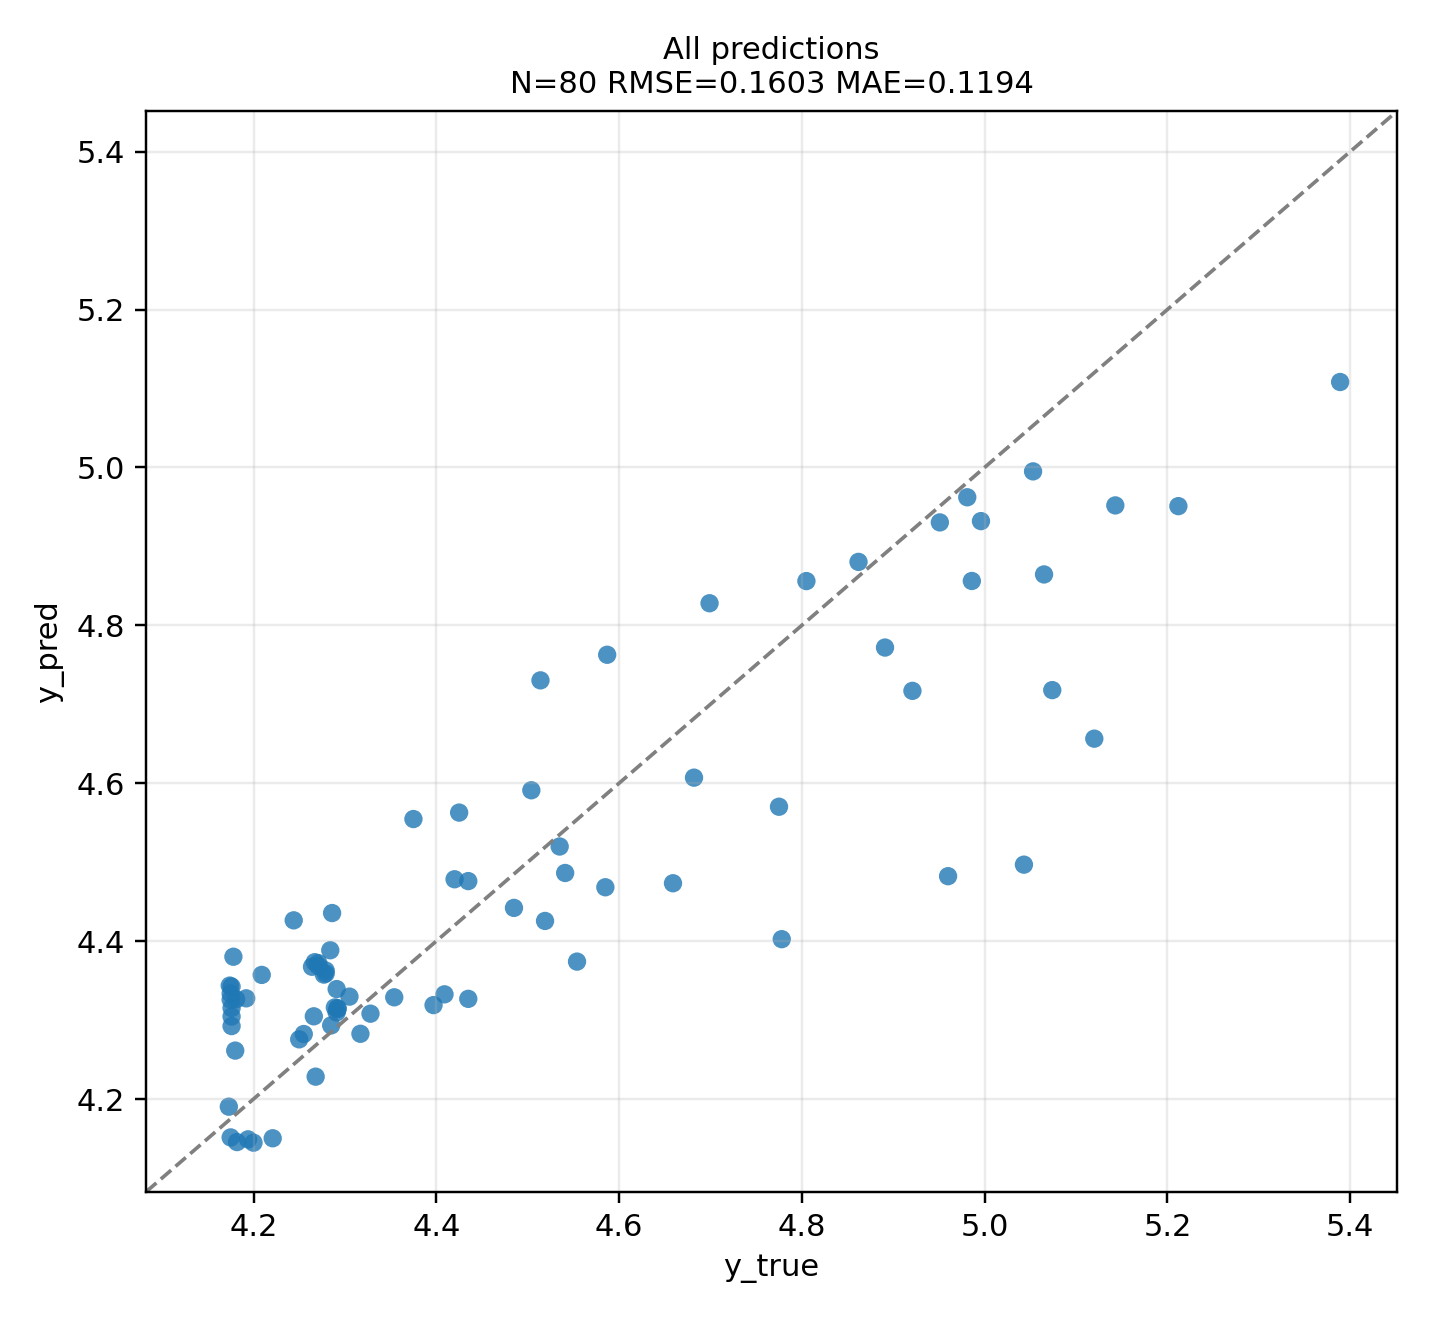

/Users/gongjin/Downloads/project_battery/battery-swelling-prediction/data/latest_test_26_5_20_2_repro/results_xgb_current_hycl_only/feature_corr__features_targets.png


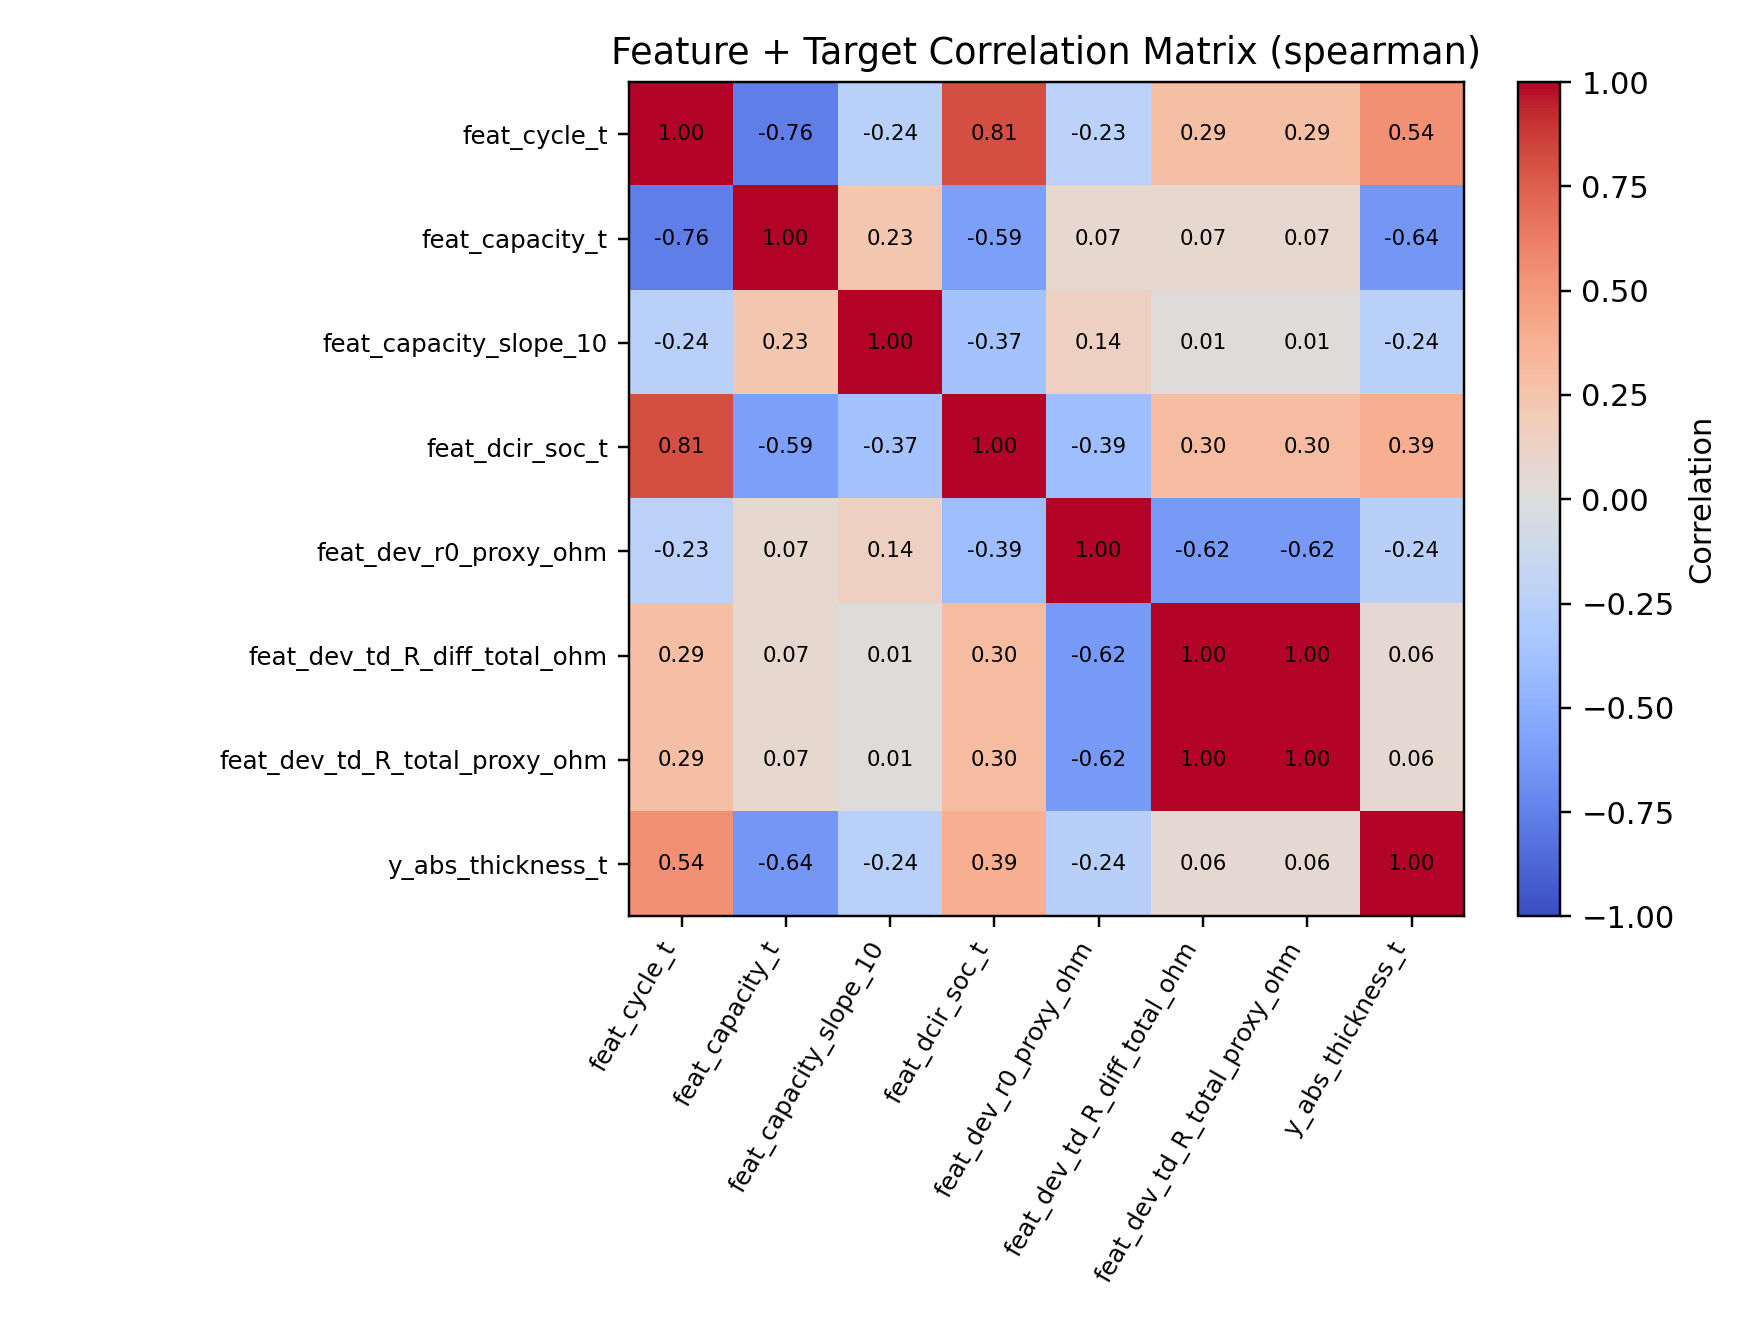

/Users/gongjin/Downloads/project_battery/battery-swelling-prediction/data/latest_test_26_5_20_2_repro/results_xgb_current_hycl_only/perm_importance__current__absolute__current_cycle__HYCL__XGBoost__mae.png


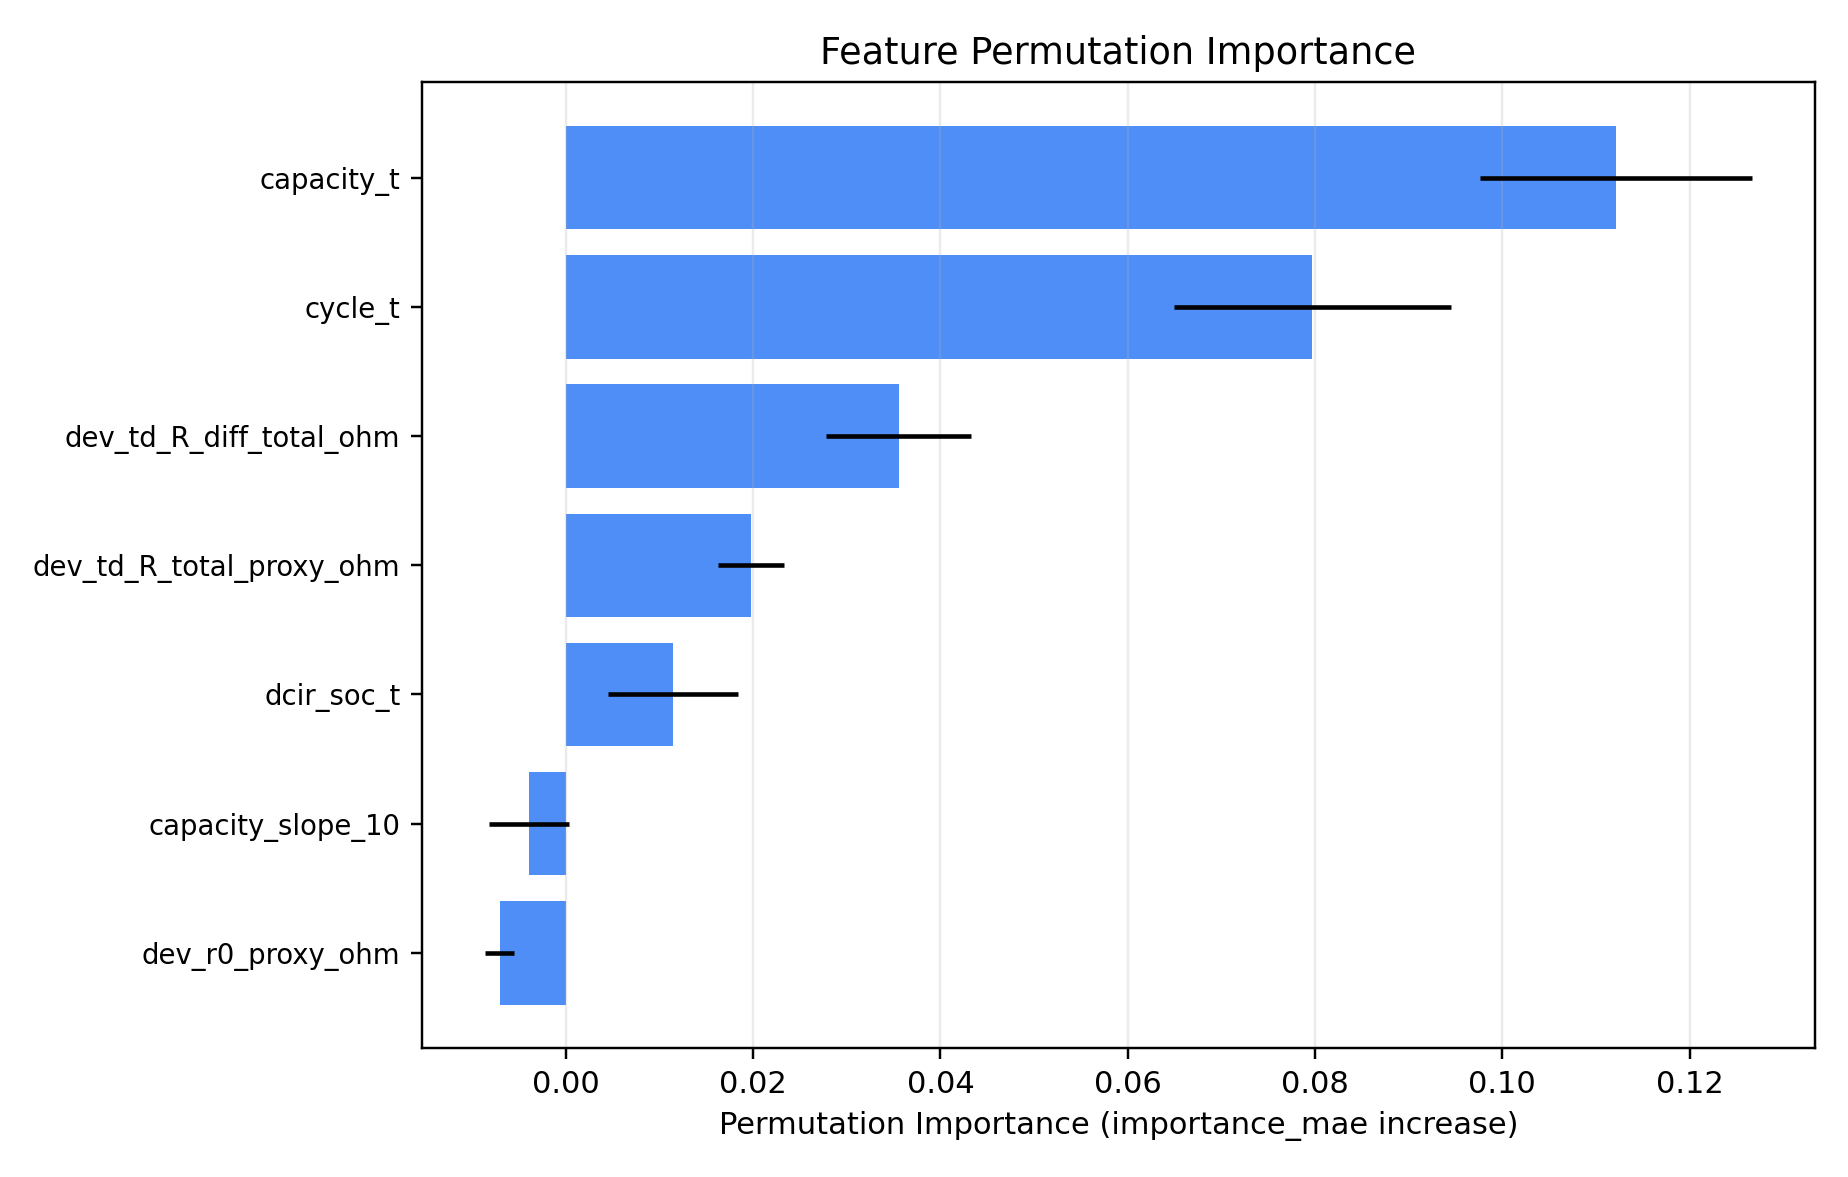

In [14]:
from IPython.display import Image, display

for name in [
    'pred_scatter__combined.png',
    'feature_corr__features_targets.png',
    'perm_importance__current__absolute__current_cycle__HYCL__XGBoost__mae.png',
]:
    p = MODEL_OUT_DIR / name
    if p.exists():
        print(p)
        display(Image(filename=str(p)))

### 7b. Retrain without `feat_capacity_slope_10` and `feat_dev_r0_proxy_ohm`

The permutation importance plot can show slightly negative values when a feature adds noise or redundancy on the held-out set.
This section retrains the model after removing `feat_capacity_slope_10` and `feat_dev_r0_proxy_ohm`, then reruns the same evaluation bundle.


/Users/gongjin/Downloads/project_battery/battery-swelling-prediction/.venv/bin/python src/train_swelling_models.py   --table_csv "/Users/gongjin/Downloads/project_battery/battery-swelling-prediction/data/latest_test_26_5_20_2_repro/feature_table_hycl_only_td_replaced.csv"   --out_dir "/Users/gongjin/Downloads/project_battery/battery-swelling-prediction/data/latest_test_26_5_20_2_repro/results_xgb_current_hycl_only_wo_neg_pi"   --target_mode current   --sample_mode rowwise   --label_mode absolute   --target_transform log   --max_input_cycle 120   --models XGBoost   --feature_set custom   --custom_features "feat_cycle_t,feat_capacity_t,feat_dcir_soc_t,feat_dev_td_R_diff_total_ohm,feat_dev_td_R_total_proxy_ohm"   --xgb_n_estimators 1200   --xgb_max_depth 4   --xgb_learning_rate 0.015   --xgb_subsample 0.85   --xgb_colsample_bytree 0.85   --xgb_min_child_weight 2   --xgb_reg_alpha 0.05   --xgb_reg_lambda 2.0   --run_tag raw_hycl_td_replaced_xgb_wo_neg_pi   --log_file "/Users/gongjin/Downlo

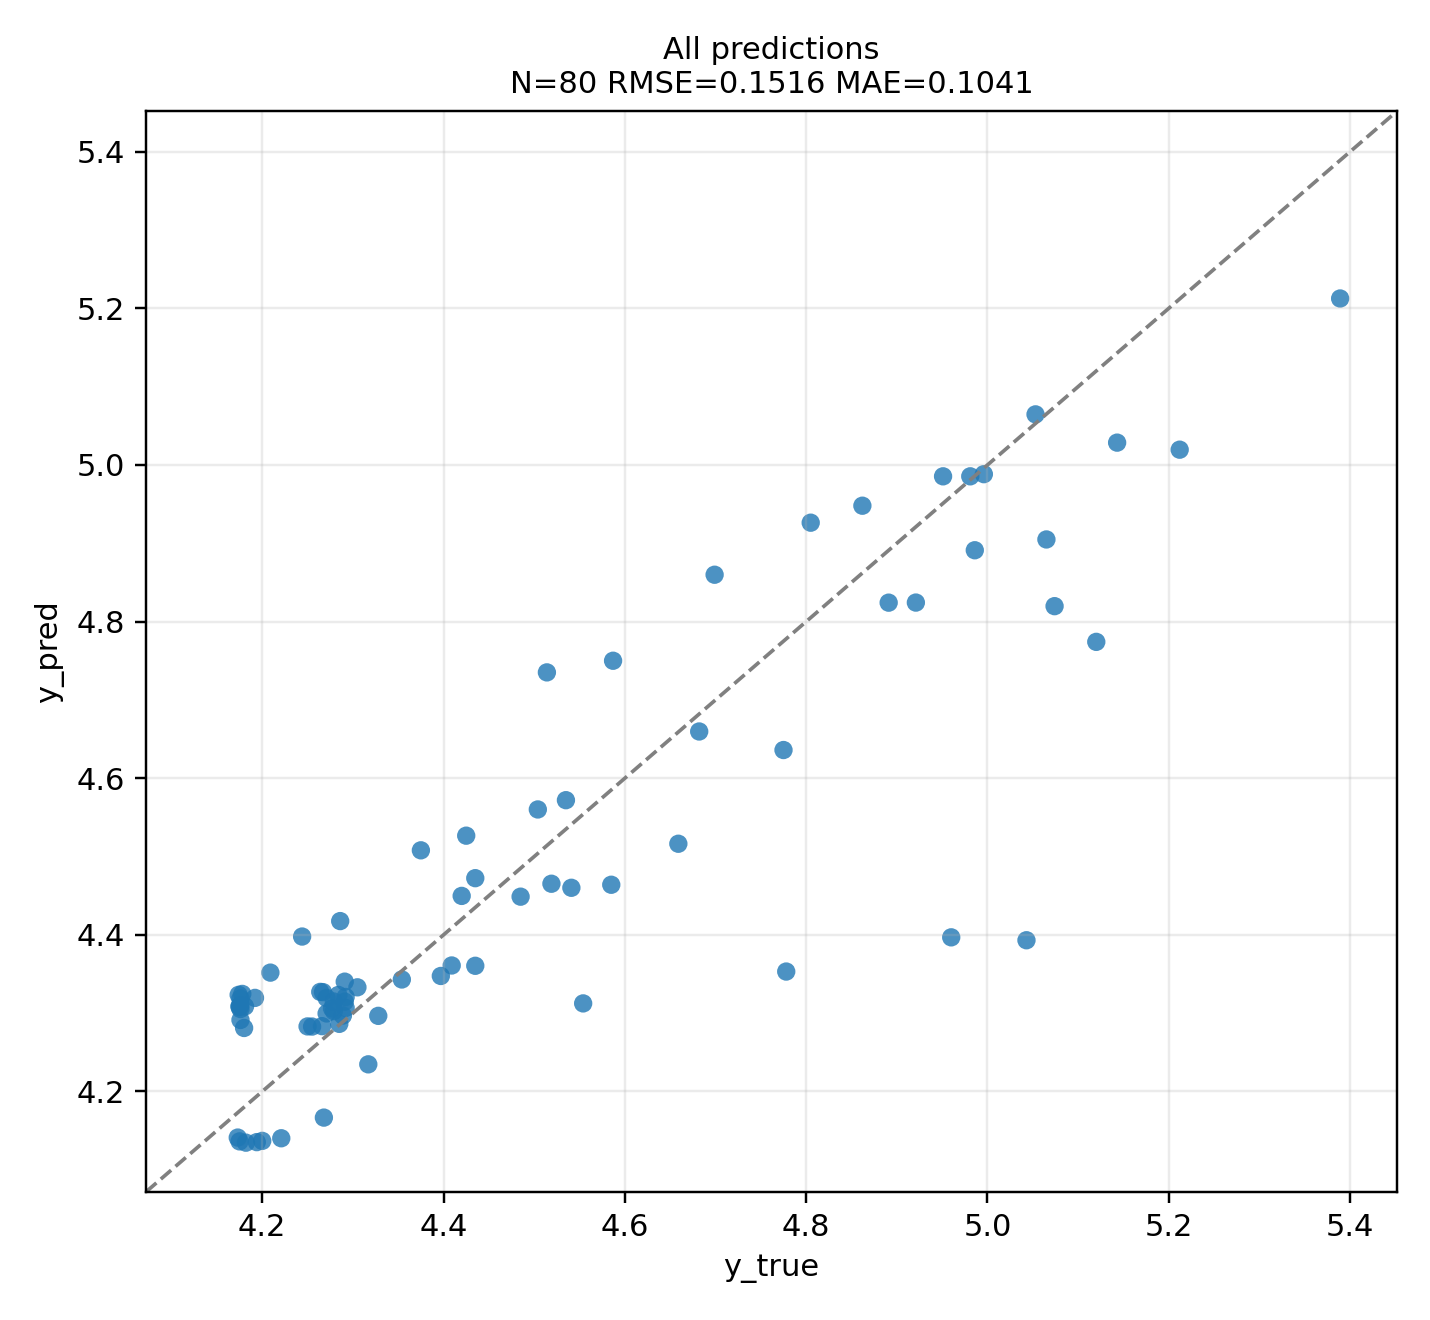

/Users/gongjin/Downloads/project_battery/battery-swelling-prediction/data/latest_test_26_5_20_2_repro/results_xgb_current_hycl_only_wo_neg_pi/feature_corr__features_targets.png


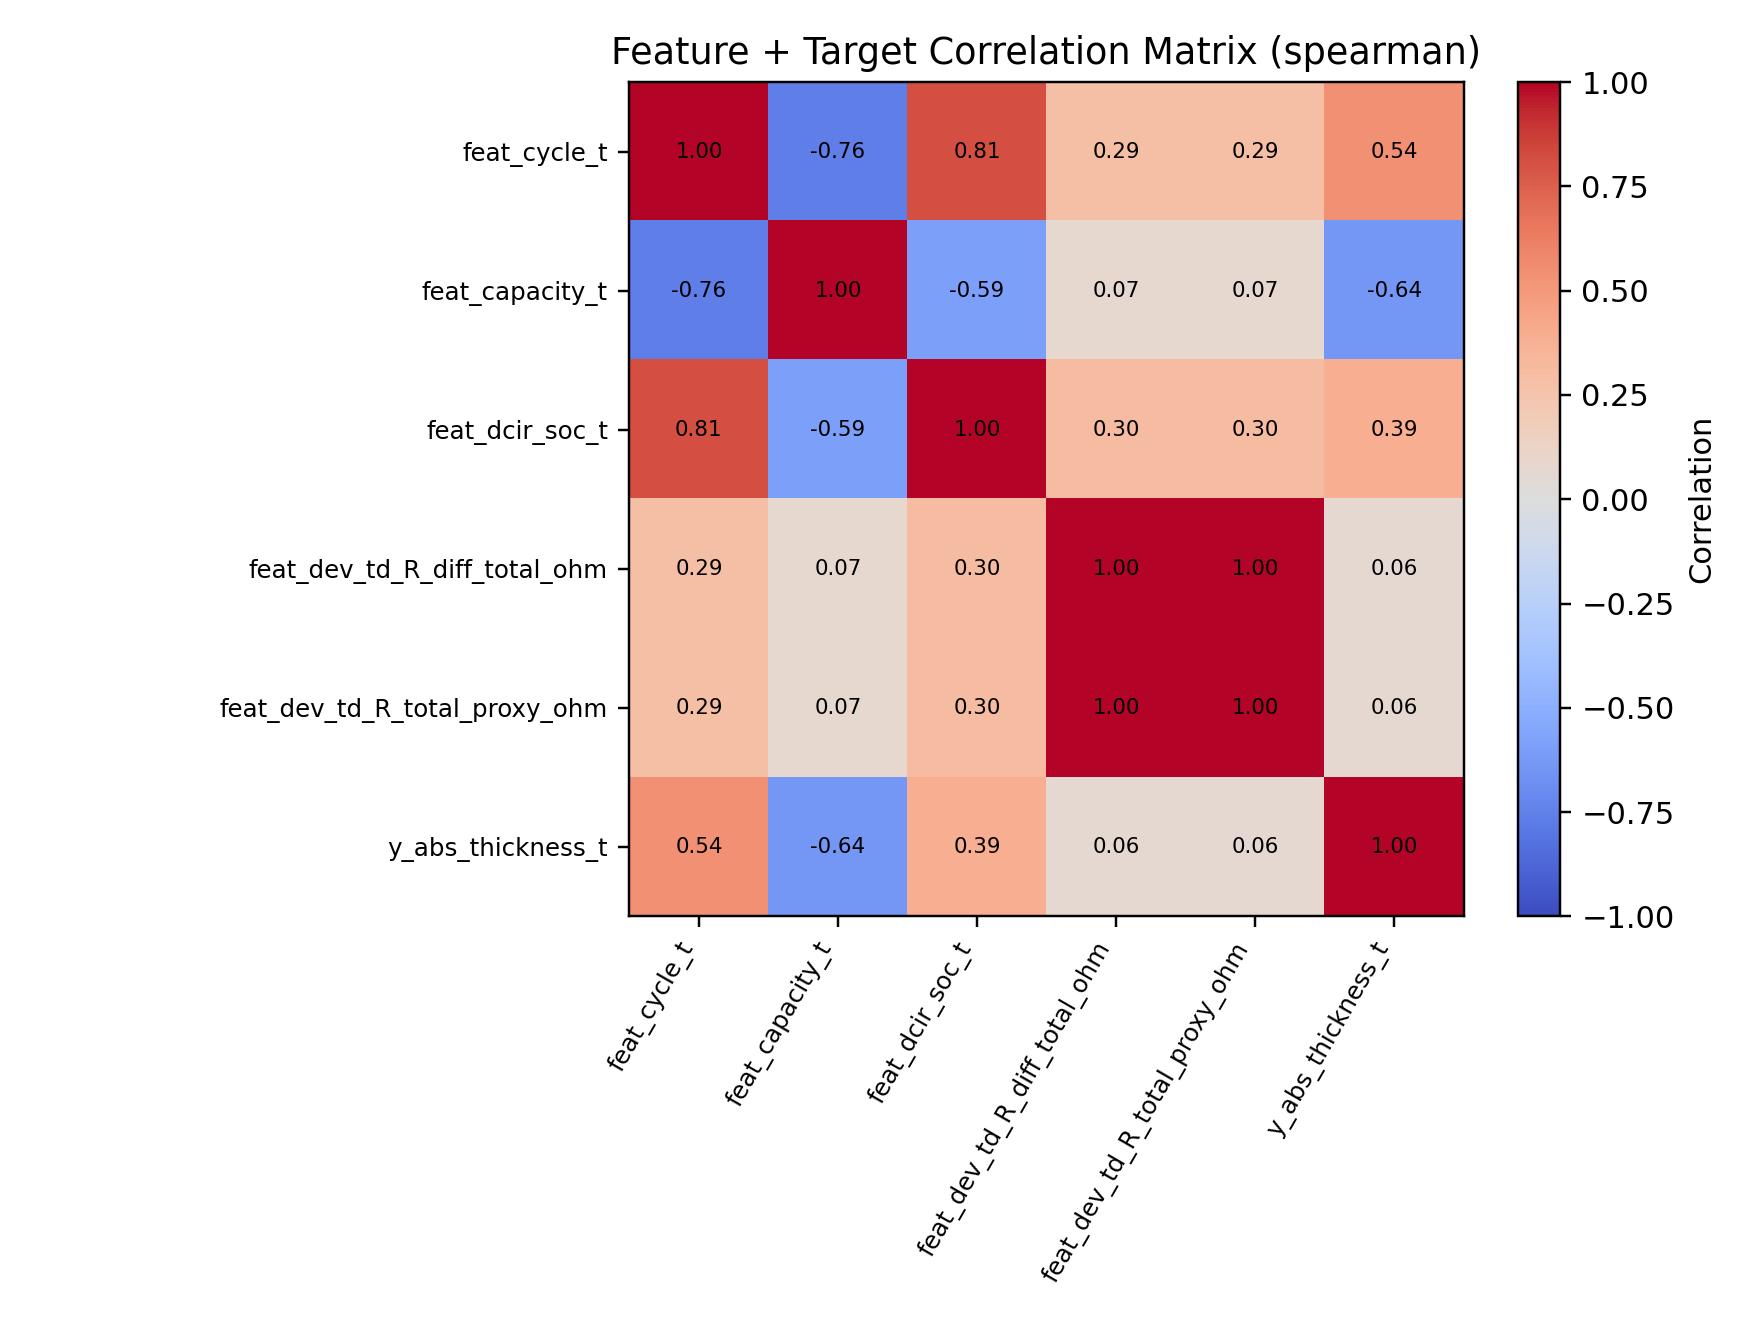

/Users/gongjin/Downloads/project_battery/battery-swelling-prediction/data/latest_test_26_5_20_2_repro/results_xgb_current_hycl_only_wo_neg_pi/perm_importance__current__absolute__current_cycle__HYCL__XGBoost__mae.png


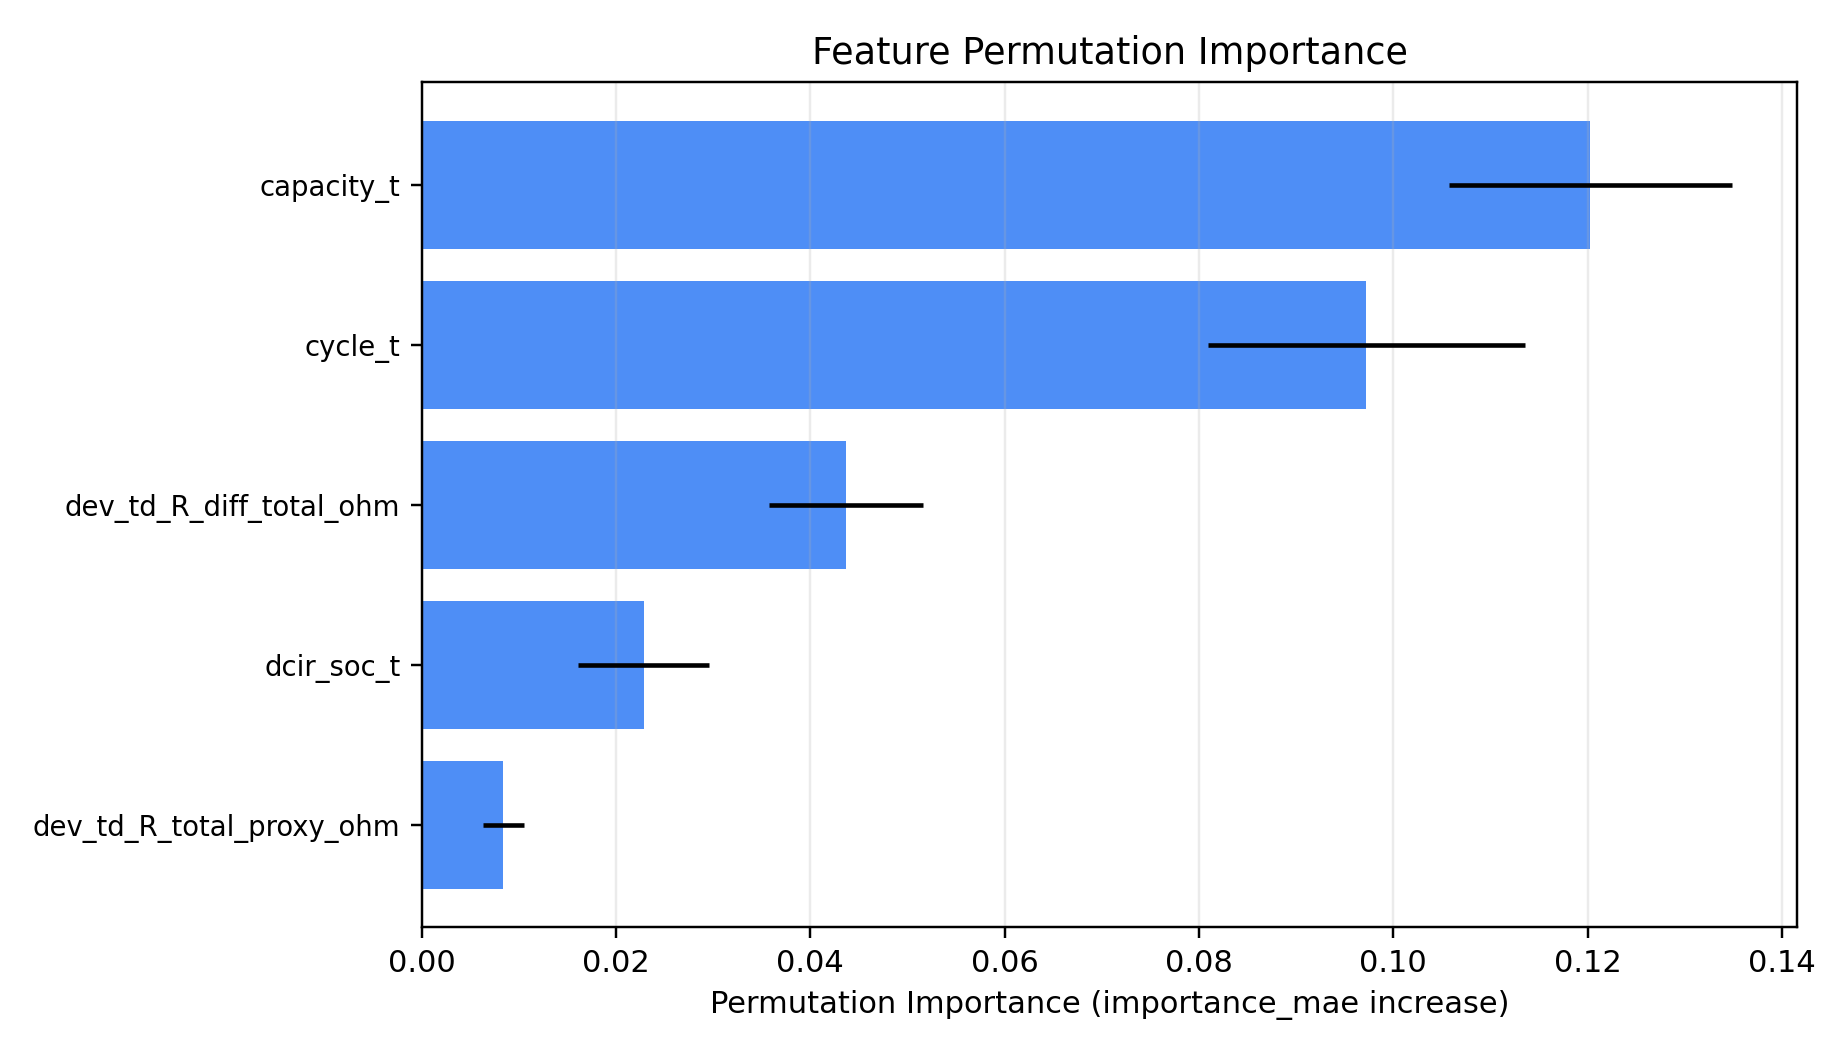

In [15]:
CUSTOM_FEATURES_DROP_NEG_PI = ",".join([
    "feat_cycle_t",
    "feat_capacity_t",
    "feat_dcir_soc_t",
    "feat_dev_td_R_diff_total_ohm",
    "feat_dev_td_R_total_proxy_ohm",
])

MODEL_OUT_DIR_DROP_NEG_PI = OUTPUT_ROOT / "results_xgb_current_hycl_only_wo_neg_pi"
MODEL_OUT_DIR_DROP_NEG_PI.mkdir(parents=True, exist_ok=True)
RESULT_RUN_TAG_DROP_NEG_PI = "raw_hycl_td_replaced_xgb_wo_neg_pi"
TRAIN_LOG_DROP_NEG_PI = LOG_DIR / "09_train_xgb_wo_neg_pi.internal.log"

cmd = f'''{VENV_PYTHON} src/train_swelling_models.py \
  --table_csv "{TRAIN_TABLE}" \
  --out_dir "{MODEL_OUT_DIR_DROP_NEG_PI}" \
  --target_mode current \
  --sample_mode rowwise \
  --label_mode absolute \
  --target_transform log \
  --max_input_cycle 120 \
  --models XGBoost \
  --feature_set custom \
  --custom_features "{CUSTOM_FEATURES_DROP_NEG_PI}" \
  --xgb_n_estimators 1200 \
  --xgb_max_depth 4 \
  --xgb_learning_rate 0.015 \
  --xgb_subsample 0.85 \
  --xgb_colsample_bytree 0.85 \
  --xgb_min_child_weight 2 \
  --xgb_reg_alpha 0.05 \
  --xgb_reg_lambda 2.0 \
  --run_tag {RESULT_RUN_TAG_DROP_NEG_PI} \
  --log_file "{TRAIN_LOG_DROP_NEG_PI}"'''
run(cmd, log_name="09_train_xgb_wo_neg_pi.log")
show_log("09_train_xgb_wo_neg_pi.log", n=120)

cmd = f'''{VENV_PYTHON} src/run_feature_analysis.py \
  --table_csv "{TRAIN_TABLE}" \
  --results_dir "{MODEL_OUT_DIR_DROP_NEG_PI}" \
  --out_dir "{MODEL_OUT_DIR_DROP_NEG_PI}" \
  --custom_features "{CUSTOM_FEATURES_DROP_NEG_PI}" \
  --group_tag HYCL \
  --target_mode current \
  --sample_mode rowwise \
  --label_mode absolute \
  --target_transform log \
  --max_input_cycle 120 \
  --model XGBoost \
  --metric mae \
  --n_repeats 30 \
  --corr_method spearman \
  --xgb_n_estimators 1200 \
  --xgb_max_depth 4 \
  --xgb_learning_rate 0.015 \
  --xgb_subsample 0.85 \
  --xgb_colsample_bytree 0.85 \
  --xgb_min_child_weight 2 \
  --xgb_reg_alpha 0.05 \
  --xgb_reg_lambda 2.0'''
run(cmd, log_name="10_feature_analysis_wo_neg_pi.log")
show_log("10_feature_analysis_wo_neg_pi.log", n=120)

from IPython.display import Image, display
for name in [
    "pred_scatter__combined.png",
    "feature_corr__features_targets.png",
    "perm_importance__current__absolute__current_cycle__HYCL__XGBoost__mae.png",
]:
    p = MODEL_OUT_DIR_DROP_NEG_PI / name
    if p.exists():
        print(p)
        display(Image(filename=str(p)))


## 8. TD-ECM voltage overlay validation

This step validates the time-domain ECM fit by overlaying the fitted voltage response on top of the measured relaxation voltage trace.
It auto-selects the best available raw example from the current raw subset using the same cycle/segment selection strategy as the feature extraction step.


/Users/gongjin/Downloads/project_battery/battery-swelling-prediction/.venv/bin/python src/plot_td_ecm_voltage_overlay.py   --raw_dir "/Users/gongjin/Downloads/project_battery/battery-swelling-prediction/data/latest_test_26_5_20_2_repro/raw_subset_hycl_one_per_serial"   --eis_prior_csv "/Users/gongjin/Downloads/project_battery/battery-swelling-prediction/data/latest_test_26_5_20_2_repro/eis_time_domain_priors_td_compatible.csv"   --prior_mode global   --prior_align_mode last_le   --cycle_mode "best"   --segment_choice "best_td"   --out_dir "/Users/gongjin/Downloads/project_battery/battery-swelling-prediction/data/latest_test_26_5_20_2_repro/results_xgb_current_hycl_only/td_ecm_overlay"
[log] /Users/gongjin/Downloads/project_battery/battery-swelling-prediction/data/latest_test_26_5_20_2_repro/logs/08_td_ecm_overlay.log
[INFO] Saved candidate summary: /Users/gongjin/Downloads/project_battery/battery-swelling-prediction/data/latest_test_26_5_20_2_repro/results_xgb_current_hycl_only/td_ecm_

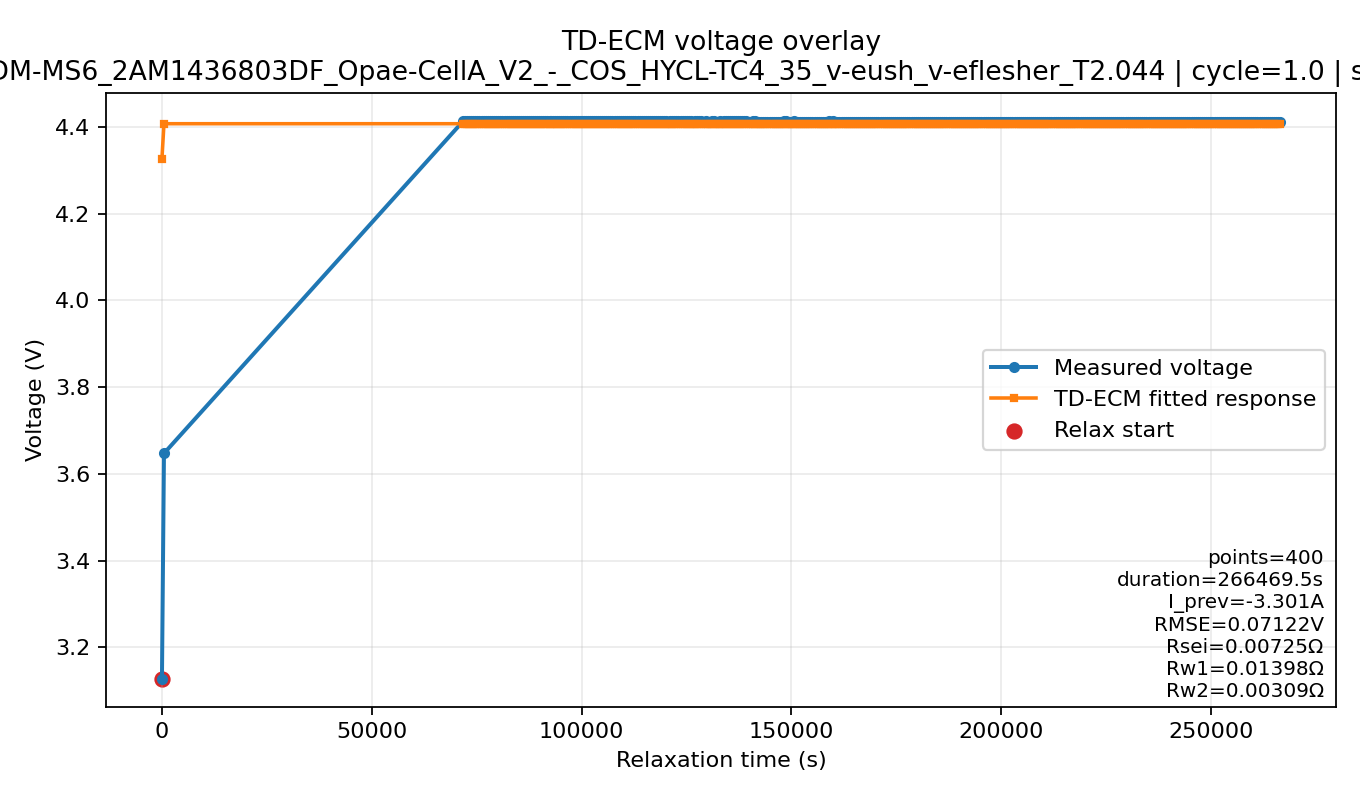

{
  "source_file": "RDM-MS6_2AM1436803DF_Opae-CellA_V2_-_COS_HYCL-TC4_35_v-eush_v-eflesher_T2.044",
  "serial_norm": "2AM1436803DF",
  "group_tag": "UNGROUPED",
  "cycle_c": 1.0,
  "segment_start_idx": 9745,
  "segment_end_idx": 11379,
  "relax_duration_s": 266469.45999999903,
  "pre_current_a": -3.301,
  "effective_points": 400,
  "fit_status": "2",
  "fit_rmse_v": 0.07121800475533407,
  "valid_component_count": 3,
  "prior_cycle_used": NaN,
  "td_v_inf_v": 4.407522580267528,
  "td_Rsei_ohm": 0.0072500362989571885,
  "td_Rw1_ohm": 0.013983750861038778,
  "td_Rw2_ohm": 0.0030883809095666,
  "t_rel_s": [
    0.0,
    480.0,
    71829.45999999903,
    72309.45999999903,
    72789.45999999903,
    73269.45999999903,
    73749.45999999903,
    74229.45999999903,
    74709.45999999903,
    75189.45999999903,
    75669.45999999903,
    76269.45999999903,
    76749.45999999903,
    77229.45999999903,
    77709.45999999903,
    78189.45999999903,
    78669.45999999903,
    79149.45999999903,
 

In [16]:
TD_OVERLAY_DIR = MODEL_OUT_DIR / "td_ecm_overlay"
TD_OVERLAY_DIR.mkdir(parents=True, exist_ok=True)

cmd = f'''{VENV_PYTHON} src/plot_td_ecm_voltage_overlay.py \
  --raw_dir "{RAW_SUBSET_DIR}" \
  --eis_prior_csv "{PRIOR_CSV}" \
  --prior_mode global \
  --prior_align_mode last_le \
  --cycle_mode "{TD_CYCLE_MODE}" \
  --segment_choice "{TD_SEGMENT_CHOICE}" \
  --out_dir "{TD_OVERLAY_DIR}"'''
run(cmd, log_name="08_td_ecm_overlay.log")
show_log("08_td_ecm_overlay.log", n=120)

from IPython.display import Image, display
overlay_png = TD_OVERLAY_DIR / "td_ecm_overlay_best_candidate.png"
overlay_meta = TD_OVERLAY_DIR / "td_ecm_overlay_best_metadata.json"
overlay_csv = TD_OVERLAY_DIR / "td_ecm_overlay_candidates.csv"
print("overlay_png =", overlay_png)
print("overlay_meta =", overlay_meta)
print("overlay_csv =", overlay_csv)
if overlay_png.exists():
    display(Image(filename=str(overlay_png)))
if overlay_meta.exists():
    print(json.dumps(json.loads(overlay_meta.read_text()), indent=2)[:4000])
if overlay_csv.exists():
    pd.read_csv(overlay_csv).head()


## 9. Frequency-domain and time-domain ECM range plots

This section generates matched range plots for the five resistance variables used in the
frequency-domain td-compatible branch:

- `R0`
- `Rsei`
- `Rct`
- `Rw1`
- `Rw2`

Outputs are saved into `MODEL_OUT_DIR` as:

- `ecm_range__frequency_domain_prior_bounds__matched5.png`
- `ecm_range__time_domain_fitted_ranges__matched5.png`
- `ecm_range__freq_vs_time__matched5.png`
- `ecm_range__freq_vs_time__matched5__shared_x.png`
- plus the corresponding `.csv` summaries


/Users/gongjin/Downloads/project_battery/battery-swelling-prediction/.venv/bin/python src/plot_ecm_range_comparison.py   --prior_csv "/Users/gongjin/Downloads/project_battery/battery-swelling-prediction/data/latest_test_26_5_20_2_repro/eis_time_domain_priors_td_compatible.csv"   --train_csv "/Users/gongjin/Downloads/project_battery/battery-swelling-prediction/data/latest_test_26_5_20_2_repro/feature_table_hycl_only_td_replaced.csv"   --out_dir "/Users/gongjin/Downloads/project_battery/battery-swelling-prediction/data/latest_test_26_5_20_2_repro/results_xgb_current_hycl_only"
[log] /Users/gongjin/Downloads/project_battery/battery-swelling-prediction/data/latest_test_26_5_20_2_repro/logs/09_ecm_range_plots.log
saved /Users/gongjin/Downloads/project_battery/battery-swelling-prediction/data/latest_test_26_5_20_2_repro/results_xgb_current_hycl_only/ecm_range__frequency_domain_prior_bounds__matched5.csv
saved /Users/gongjin/Downloads/project_battery/battery-swelling-prediction/data/latest_te

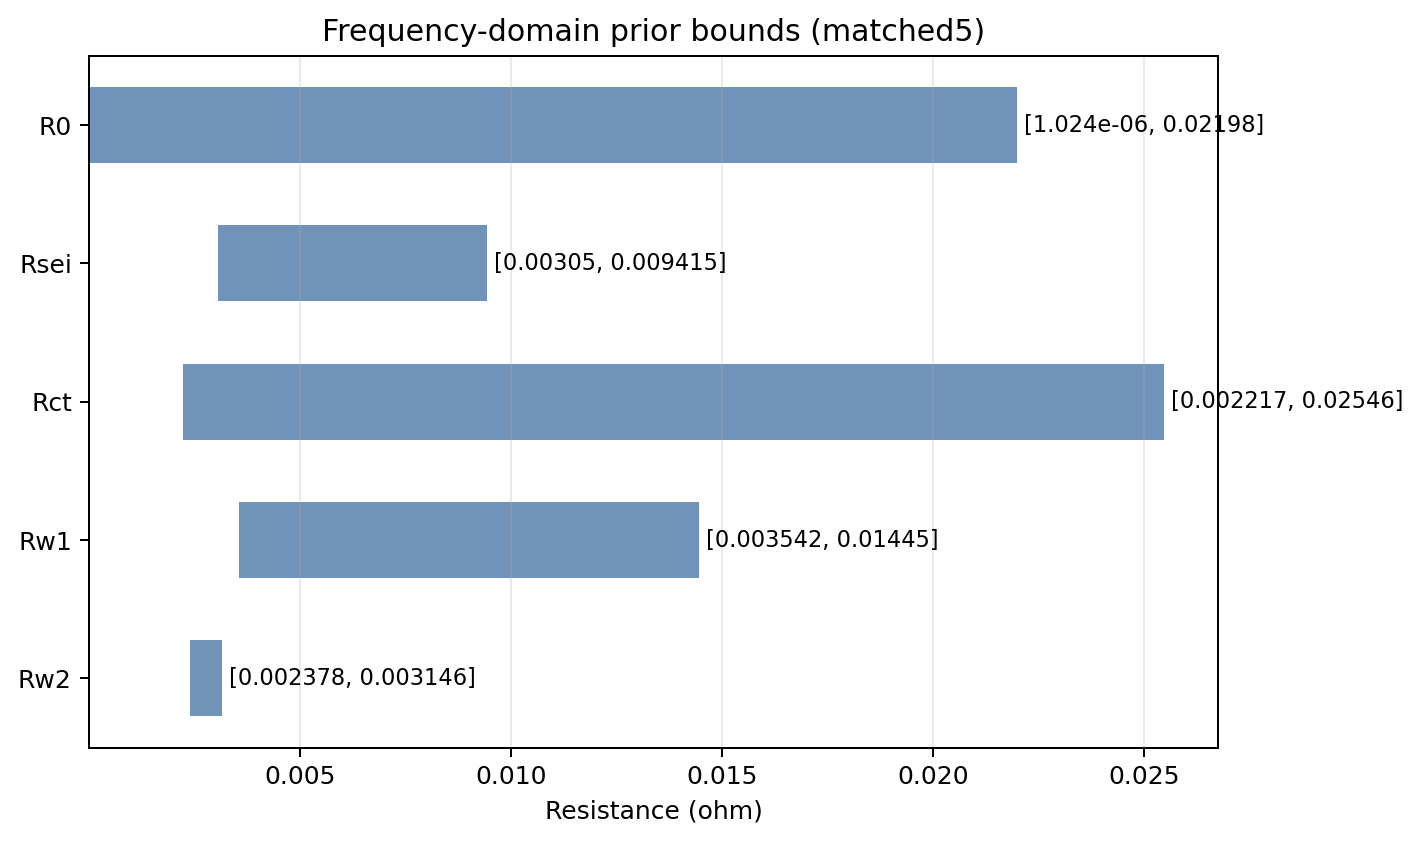

/Users/gongjin/Downloads/project_battery/battery-swelling-prediction/data/latest_test_26_5_20_2_repro/results_xgb_current_hycl_only/ecm_range__time_domain_fitted_ranges__matched5.png


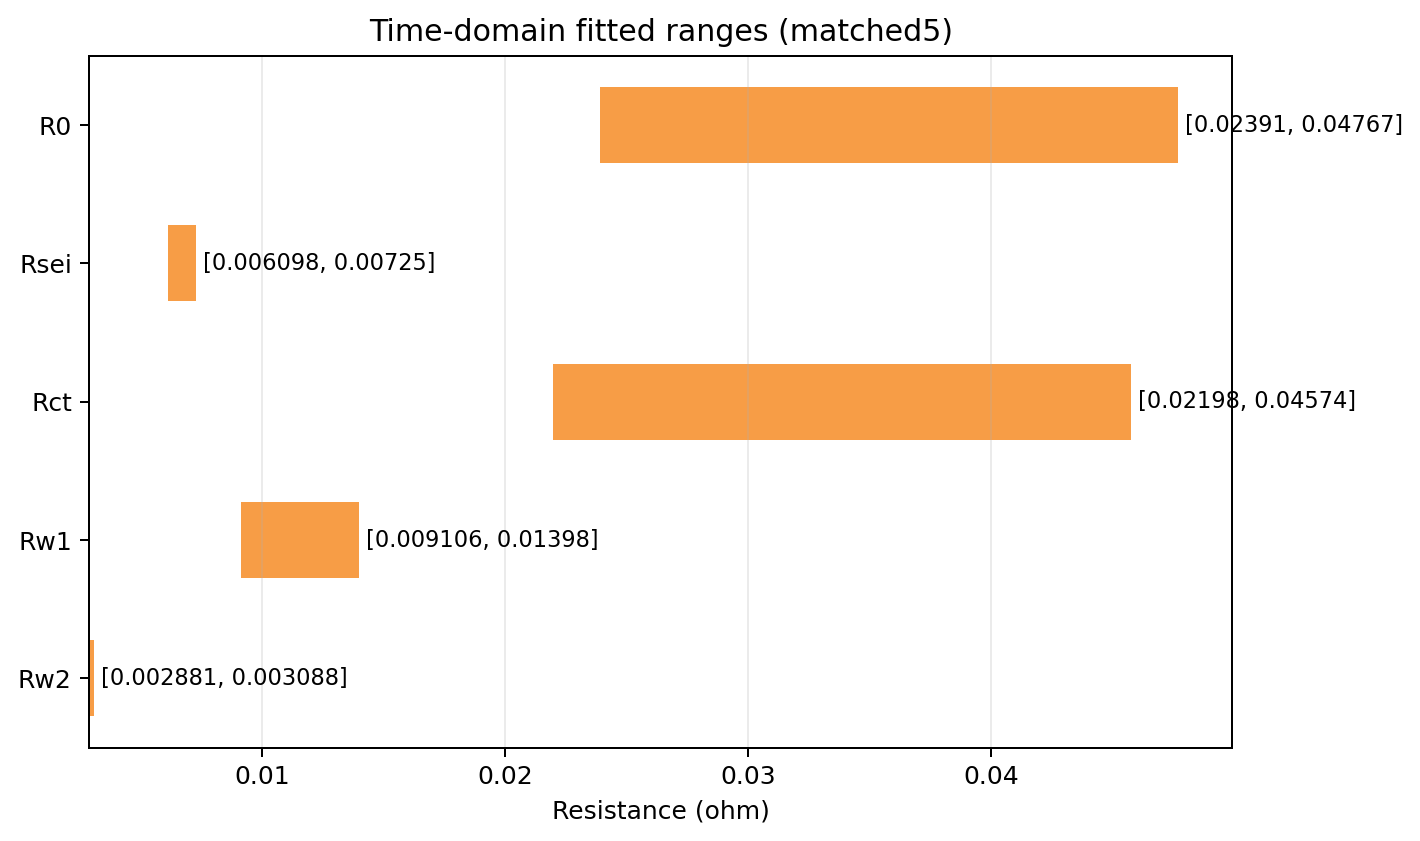

/Users/gongjin/Downloads/project_battery/battery-swelling-prediction/data/latest_test_26_5_20_2_repro/results_xgb_current_hycl_only/ecm_range__freq_vs_time__matched5.png


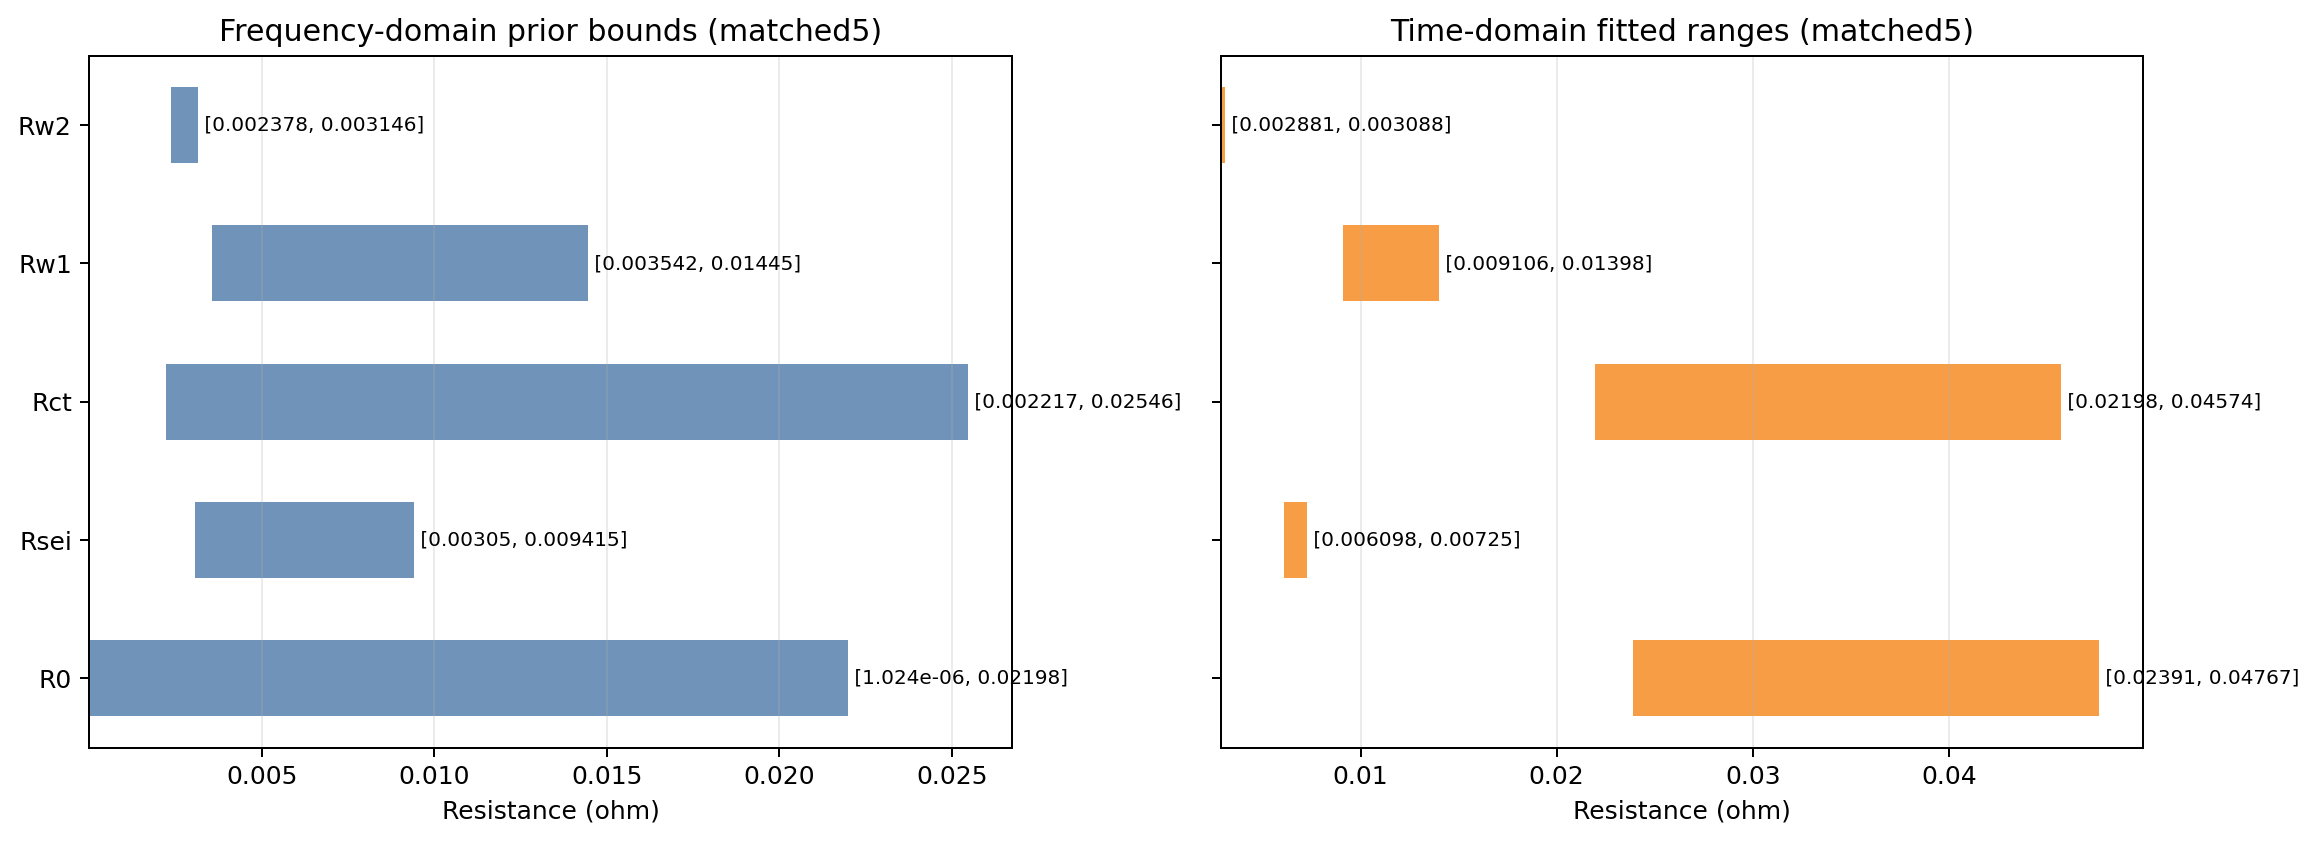

/Users/gongjin/Downloads/project_battery/battery-swelling-prediction/data/latest_test_26_5_20_2_repro/results_xgb_current_hycl_only/ecm_range__freq_vs_time__matched5__shared_x.png


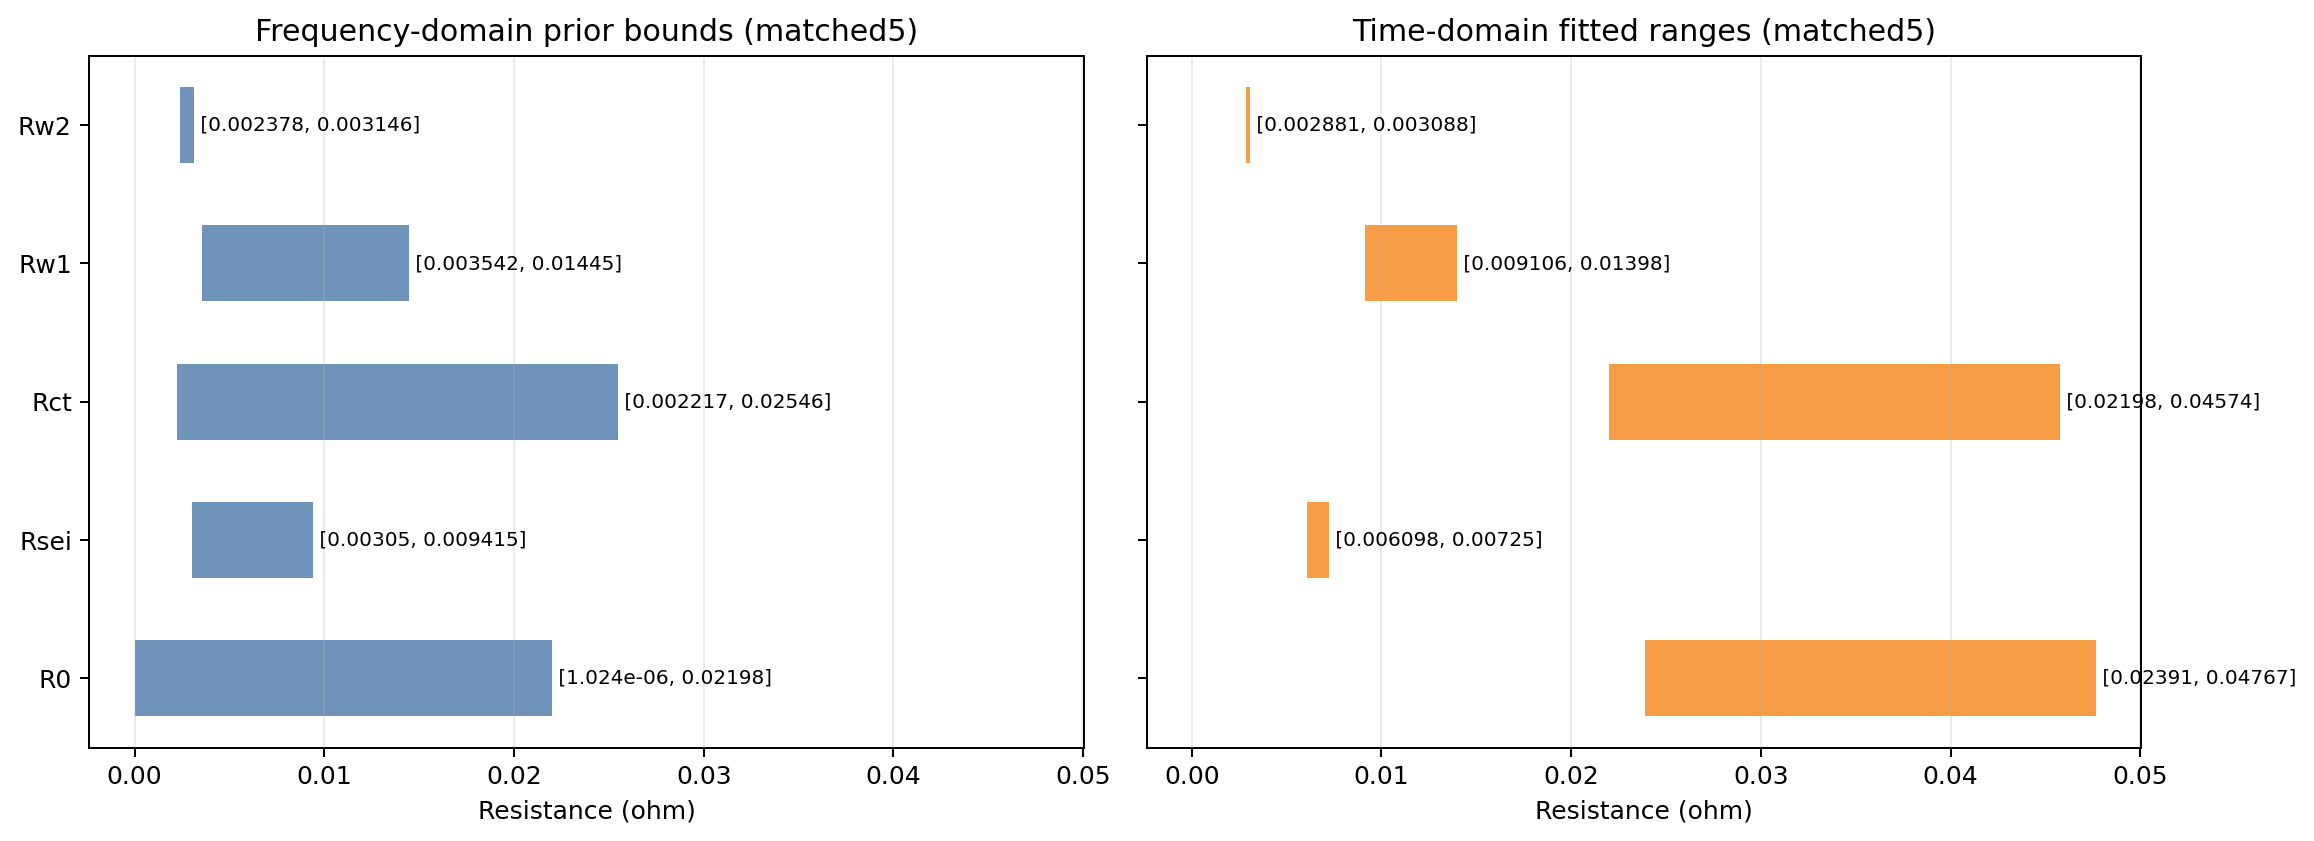

/Users/gongjin/Downloads/project_battery/battery-swelling-prediction/data/latest_test_26_5_20_2_repro/results_xgb_current_hycl_only/ecm_range__frequency_domain_prior_bounds__matched5.csv


,parameter,lb,ub,status
0,R0,0.000001,0.021983,ok
1,Rsei,0.003050,0.009415,ok
2,Rct,0.002217,0.025463,ok
3,Rw1,0.003542,0.014453,ok
4,Rw2,0.002378,0.003146,ok


/Users/gongjin/Downloads/project_battery/battery-swelling-prediction/data/latest_test_26_5_20_2_repro/results_xgb_current_hycl_only/ecm_range__time_domain_fitted_ranges__matched5.csv


,parameter,lb,ub,status
0,R0,0.023909,0.047669,ok
1,Rsei,0.006098,0.007250,ok
2,Rct,0.021980,0.045741,ok
3,Rw1,0.009106,0.013984,ok
4,Rw2,0.002881,0.003088,ok


In [17]:
cmd = f'''{VENV_PYTHON} src/plot_ecm_range_comparison.py \
  --prior_csv "{PRIOR_CSV}" \
  --train_csv "{TRAIN_TABLE}" \
  --out_dir "{MODEL_OUT_DIR}"'''
run(cmd, log_name="09_ecm_range_plots.log")
show_log("09_ecm_range_plots.log", n=120)

from IPython.display import Image, display
for name in [
    "ecm_range__frequency_domain_prior_bounds__matched5.png",
    "ecm_range__time_domain_fitted_ranges__matched5.png",
    "ecm_range__freq_vs_time__matched5.png",
    "ecm_range__freq_vs_time__matched5__shared_x.png",
]:
    p = MODEL_OUT_DIR / name
    if p.exists():
        print(p)
        display(Image(filename=str(p)))

for csv_name in [
    "ecm_range__frequency_domain_prior_bounds__matched5.csv",
    "ecm_range__time_domain_fitted_ranges__matched5.csv",
]:
    p = MODEL_OUT_DIR / csv_name
    if p.exists():
        print(p)
        display(pd.read_csv(p))


## 9. Final notes

Recommended things to record after each run:

- dataset paths used
- whether the run is hybrid or device-oriented
- prior mode (`global`, `serial_cycle`, etc.)
- final feature list
- final `MAE / RMSE`
- key plots
- any failure modes such as `insufficient_points`